In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning models (REGRESSION)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Model evaluation (both regression and classification metrics)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Regression metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix  # Classification metrics
from sklearn.metrics import classification_report, roc_curve, auc

# Model selection and feature selection
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Progress bar
from tqdm.notebook import tqdm
import time


In [25]:
x_train_scaled = pd.read_csv("data/x_train_scaled.csv").sort_values(by="video_id", ascending=True)
x_test_scaled = pd.read_csv("data/x_test_scaled.csv").sort_values(by="video_id", ascending=True)

x_train_unscaled = pd.read_csv("data/x_train_unscaled.csv").sort_values(by="video_id", ascending=True)
x_test_unscaled = pd.read_csv("data/x_test_unscaled.csv").sort_values(by="video_id", ascending=True)

y_train = pd.read_csv("data/train_y.csv").sort_values(by="video_id", ascending=True)
y_test = pd.read_csv("data/test_y.csv").sort_values(by="video_id", ascending=True)



CONTINUOUS TARGET VARIABLE ANALYSIS

📊 Continuous Target Variable Summary:
   Threshold for binary evaluation: 0.8
   Label column: label

📊 Training Set (Continuous Values):
   Min: 0.0000
   Max: 1.0000
   Mean: 0.8151
   Std: 0.1613
   Samples: 140

📊 Test Set (Continuous Values):
   Min: 0.5000
   Max: 1.0000
   Mean: 0.7913
   Std: 0.1462
   Samples: 42

📊 Binary Classification Reference (Threshold = 0.8):
   Training - Class 0 (Low, < 0.8): 51 samples (36.4%)
   Training - Class 1 (High, >= 0.8): 89 samples (63.6%)
   Test - Class 0 (Low, < 0.8): 21 samples (50.0%)
   Test - Class 1 (High, >= 0.8): 21 samples (50.0%)

   ⚠️  Note: Binary labels are for evaluation reference only, not for training!


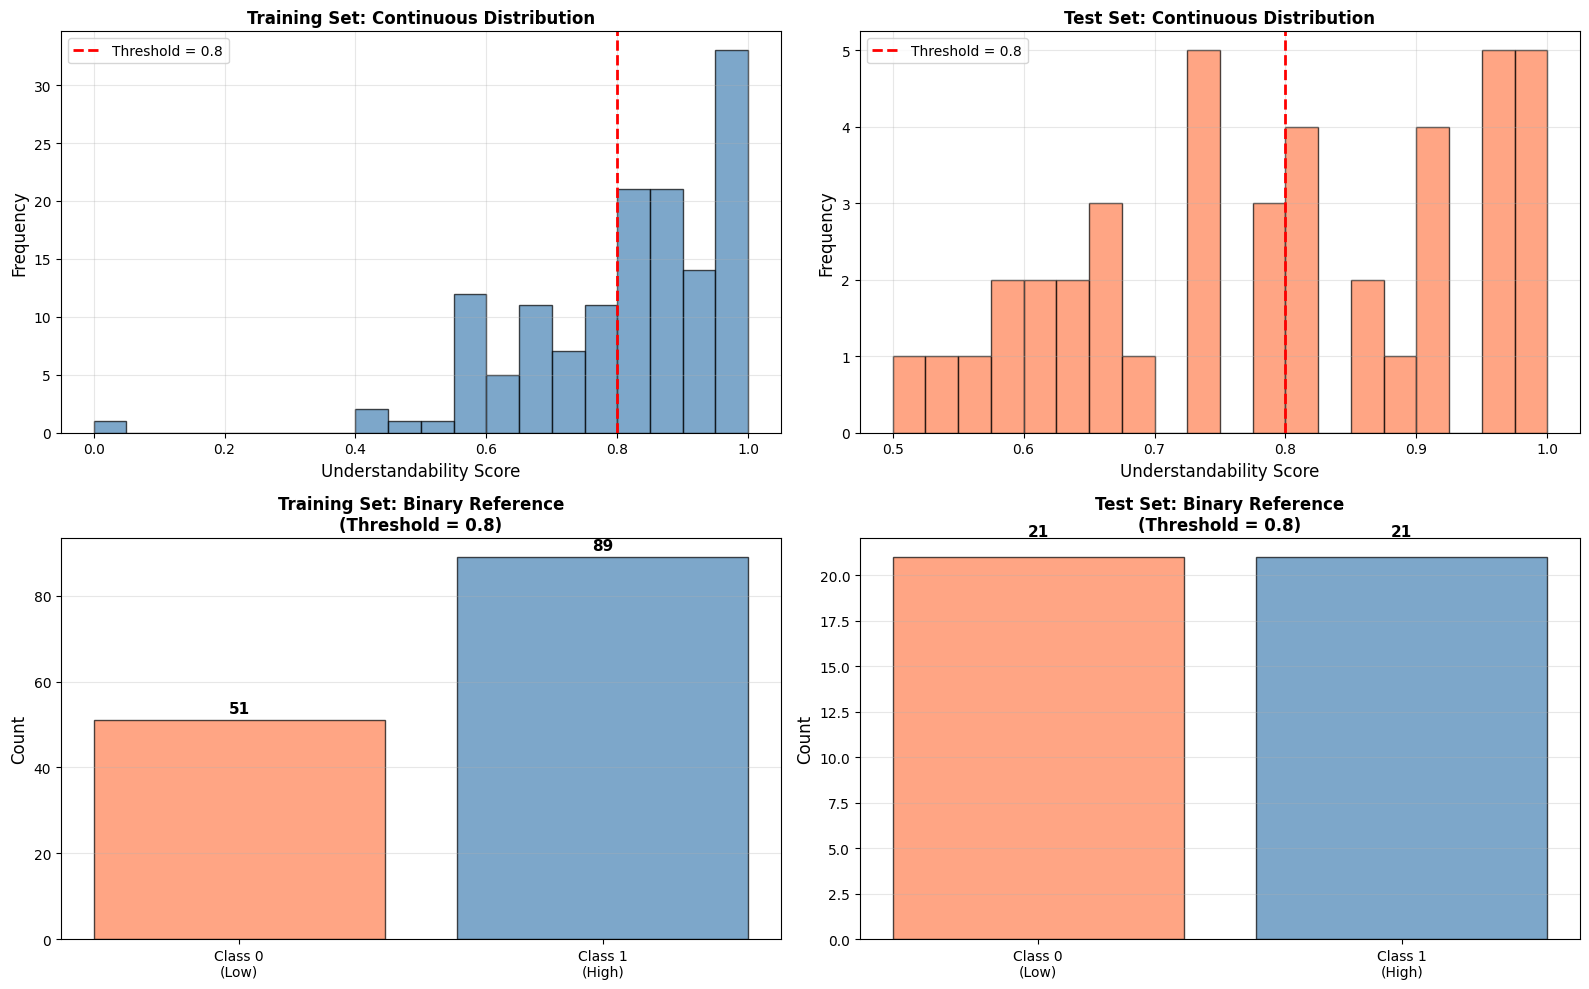


✅ Continuous target variable prepared for regression training!
   Binary labels are available for evaluation reference only.


In [26]:
# ============================================================================
# CONTINUOUS TARGET VARIABLE ANALYSIS
# ============================================================================
# Keep continuous understandability score for regression training
# Will convert to binary labels only for evaluation purposes (threshold = 0.8)
# ============================================================================

print("=" * 80)
print("CONTINUOUS TARGET VARIABLE ANALYSIS")
print("=" * 80)

threshold = 0.8  # Threshold for binary classification evaluation

def convert_to_label(y, threshold=0.8):
    """Convert continuous value to binary label (for evaluation only)"""
    return 1 if y >= threshold else 0

# Get label column name
label_col = y_train.columns[1] if 'video_id' in y_train.columns else y_train.columns[0]

# Keep continuous values for training
y_train_continuous = y_train[label_col].values
y_test_continuous = y_test[label_col].values

# Also create binary labels for evaluation reference (not for training)
y_train_binary_ref = np.array([convert_to_label(y, threshold) for y in y_train_continuous])
y_test_binary_ref = np.array([convert_to_label(y, threshold) for y in y_test_continuous])

print(f"\n📊 Continuous Target Variable Summary:")
print(f"   Threshold for binary evaluation: {threshold}")
print(f"   Label column: {label_col}")

print(f"\n📊 Training Set (Continuous Values):")
print(f"   Min: {y_train_continuous.min():.4f}")
print(f"   Max: {y_train_continuous.max():.4f}")
print(f"   Mean: {y_train_continuous.mean():.4f}")
print(f"   Std: {y_train_continuous.std():.4f}")
print(f"   Samples: {len(y_train_continuous)}")

print(f"\n📊 Test Set (Continuous Values):")
print(f"   Min: {y_test_continuous.min():.4f}")
print(f"   Max: {y_test_continuous.max():.4f}")
print(f"   Mean: {y_test_continuous.mean():.4f}")
print(f"   Std: {y_test_continuous.std():.4f}")
print(f"   Samples: {len(y_test_continuous)}")

print(f"\n📊 Binary Classification Reference (Threshold = {threshold}):")
train_dist = pd.Series(y_train_binary_ref).value_counts().sort_index()
test_dist = pd.Series(y_test_binary_ref).value_counts().sort_index()
print(f"   Training - Class 0 (Low, < {threshold}): {train_dist.get(0, 0)} samples ({train_dist.get(0, 0)/len(y_train_binary_ref)*100:.1f}%)")
print(f"   Training - Class 1 (High, >= {threshold}): {train_dist.get(1, 0)} samples ({train_dist.get(1, 0)/len(y_train_binary_ref)*100:.1f}%)")
print(f"   Test - Class 0 (Low, < {threshold}): {test_dist.get(0, 0)} samples ({test_dist.get(0, 0)/len(y_test_binary_ref)*100:.1f}%)")
print(f"   Test - Class 1 (High, >= {threshold}): {test_dist.get(1, 0)} samples ({test_dist.get(1, 0)/len(y_test_binary_ref)*100:.1f}%)")
print(f"\n   ⚠️  Note: Binary labels are for evaluation reference only, not for training!")

# Visualize distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Training set continuous distribution
axes[0, 0].hist(y_train_continuous, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')
axes[0, 0].set_xlabel('Understandability Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Training Set: Continuous Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Test set continuous distribution
axes[0, 1].hist(y_test_continuous, bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold}')
axes[0, 1].set_xlabel('Understandability Score', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Test Set: Continuous Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Training set binary reference
axes[1, 0].bar(['Class 0\n(Low)', 'Class 1\n(High)'], 
            [train_dist.get(0, 0), train_dist.get(1, 0)],
            color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title(f'Training Set: Binary Reference\n(Threshold = {threshold})', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate([train_dist.get(0, 0), train_dist.get(1, 0)]):
    axes[1, 0].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 4: Test set binary reference
axes[1, 1].bar(['Class 0\n(Low)', 'Class 1\n(High)'], 
            [test_dist.get(0, 0), test_dist.get(1, 0)],
            color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].set_title(f'Test Set: Binary Reference\n(Threshold = {threshold})', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate([test_dist.get(0, 0), test_dist.get(1, 0)]):
    axes[1, 1].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✅ Continuous target variable prepared for regression training!")
print("   Binary labels are available for evaluation reference only.")
print("=" * 80)

In [27]:
# ============================================================================
# EVALUATION HELPER FUNCTIONS
# ============================================================================
# Functions to evaluate regression predictions as binary classification
# ============================================================================

def evaluate_regression_as_classification(y_true_continuous, y_pred_continuous, threshold=0.8):
    """
    Evaluate regression predictions as binary classification using a threshold.
    
    Parameters:
    -----------
    y_true_continuous : array-like
        True continuous values
    y_pred_continuous : array-like
        Predicted continuous values
    threshold : float, default=0.8
        Threshold to convert continuous values to binary labels
    
    Returns:
    --------
    dict : Dictionary containing classification metrics
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
    
    # Convert to binary labels
    y_true_binary = np.array([1 if y >= threshold else 0 for y in y_true_continuous])
    y_pred_binary = np.array([1 if y >= threshold else 0 for y in y_pred_continuous])
    
    # Calculate regression metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    mse = mean_squared_error(y_true_continuous, y_pred_continuous)
    mae = mean_absolute_error(y_true_continuous, y_pred_continuous)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_continuous, y_pred_continuous)
    
    # Calculate classification metrics
    accuracy = accuracy_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
    
    # Try to calculate AUC (need probabilities, use continuous predictions as proxy)
    try:
        # Use continuous predictions as probabilities (normalized to [0, 1])
        y_pred_proba = (y_pred_continuous - y_pred_continuous.min()) / (y_pred_continuous.max() - y_pred_continuous.min() + 1e-10)
        auc = roc_auc_score(y_true_binary, y_pred_proba)
    except:
        auc = None
    
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    
    return {
        'regression_metrics': {
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'r2': r2
        },
        'classification_metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        },
        'confusion_matrix': cm,
        'y_true_binary': y_true_binary,
        'y_pred_binary': y_pred_binary,
        'y_pred_proba': y_pred_proba if 'y_pred_proba' in locals() else None
    }

print("=" * 80)
print("EVALUATION HELPER FUNCTIONS LOADED")
print("=" * 80)
print("\n✅ Function 'evaluate_regression_as_classification' is ready to use!")
print("   This function evaluates regression predictions as binary classification")
print("   using threshold =", threshold)
print("=" * 80)


EVALUATION HELPER FUNCTIONS LOADED

✅ Function 'evaluate_regression_as_classification' is ready to use!
   This function evaluates regression predictions as binary classification
   using threshold = 0.8


In [28]:
# ============================================================================
# DATA PREPARATION
# ============================================================================
# Align X and y data, prepare features for model training
# ============================================================================

print("=" * 80)
print("DATA PREPARATION")
print("=" * 80)

# Step 1: Align data by video_id
print("\n📊 Step 1: Aligning data by video_id...")

# Get video_ids from each dataset
train_video_ids_x = set(x_train_scaled['video_id'].unique())
test_video_ids_x = set(x_test_scaled['video_id'].unique())
train_video_ids_y = set(y_train['video_id'].unique())
test_video_ids_y = set(y_test['video_id'].unique())

# Find common video_ids
train_common = sorted(list(train_video_ids_x & train_video_ids_y))
test_common = sorted(list(test_video_ids_x & test_video_ids_y))

print(f"   Train: {len(train_common)} common video_ids")
print(f"   Test: {len(test_common)} common video_ids")

# Filter to only common video_ids
x_train_aligned = x_train_scaled[x_train_scaled['video_id'].isin(train_common)].sort_values('video_id').reset_index(drop=True)
x_test_aligned = x_test_scaled[x_test_scaled['video_id'].isin(test_common)].sort_values('video_id').reset_index(drop=True)
y_train_aligned = y_train[y_train['video_id'].isin(train_common)].sort_values('video_id').reset_index(drop=True)
y_test_aligned = y_test[y_test['video_id'].isin(test_common)].sort_values('video_id').reset_index(drop=True)

# Step 2: Prepare features and labels (using CONTINUOUS values for regression)
print("\n📊 Step 2: Preparing features and labels...")
print("   ⚠️  Using CONTINUOUS target values for regression training")

# Remove video_id from features
X_train = x_train_aligned.drop(columns=['video_id']).values
X_test = x_test_aligned.drop(columns=['video_id']).values

# Get label column name
label_col = y_train.columns[1] if 'video_id' in y_train.columns else y_train.columns[0]

# Use CONTINUOUS values for training (not binary labels)
y_train_continuous_aligned = y_train_aligned[label_col].values
y_test_continuous_aligned = y_test_aligned[label_col].values

# Also create binary labels for evaluation reference (aligned with continuous values)
y_train_binary_aligned = np.array([convert_to_label(y, threshold) for y in y_train_continuous_aligned])
y_test_binary_aligned = np.array([convert_to_label(y, threshold) for y in y_test_continuous_aligned])

# For convenience, also create shorter names
y_train = y_train_continuous_aligned
y_test = y_test_continuous_aligned

# Verify alignment
print(f"\n✅ Verification:")
print(f"   X_train shape: {X_train.shape} (samples: {X_train.shape[0]}, features: {X_train.shape[1]})")
print(f"   y_train (continuous) shape: {y_train.shape} (samples: {len(y_train)})")
print(f"   y_train (binary ref) shape: {y_train_binary_aligned.shape} (samples: {len(y_train_binary_aligned)})")
print(f"   X_test shape: {X_test.shape} (samples: {X_test.shape[0]}, features: {X_test.shape[1]})")
print(f"   y_test (continuous) shape: {y_test.shape} (samples: {len(y_test)})")
print(f"   y_test (binary ref) shape: {y_test_binary_aligned.shape} (samples: {len(y_test_binary_aligned)})")

if X_train.shape[0] != len(y_train):
    raise ValueError(f"❌ MISMATCH: X_train has {X_train.shape[0]} samples but y_train has {len(y_train)} samples!")
if X_test.shape[0] != len(y_test):
    raise ValueError(f"❌ MISMATCH: X_test has {X_test.shape[0]} samples but y_test has {len(y_test)} samples!")

# Get feature names for later use
feature_names = x_train_aligned.drop(columns=['video_id']).columns.tolist()

print(f"\n✅ Data prepared successfully!")
print(f"   Features: {len(feature_names)}")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print("=" * 80)

DATA PREPARATION

📊 Step 1: Aligning data by video_id...
   Train: 140 common video_ids
   Test: 42 common video_ids

📊 Step 2: Preparing features and labels...
   ⚠️  Using CONTINUOUS target values for regression training

✅ Verification:
   X_train shape: (140, 31) (samples: 140, features: 31)
   y_train (continuous) shape: (140,) (samples: 140)
   y_train (binary ref) shape: (140,) (samples: 140)
   X_test shape: (42, 31) (samples: 42, features: 31)
   y_test (continuous) shape: (42,) (samples: 42)
   y_test (binary ref) shape: (42,) (samples: 42)

✅ Data prepared successfully!
   Features: 31
   Training samples: 140
   Test samples: 42


## Logistc Regression

In [29]:
# ============================================================================
# BASELINE MODEL: Simple Linear Regression (No Feature Selection)
# ============================================================================
# Evaluate baseline performance before feature selection and hyperparameter tuning
# Uses continuous target values for regression training
# ============================================================================

print("=" * 80)
print("BASELINE MODEL EVALUATION (REGRESSION)")
print("=" * 80)

# Define baseline model (Linear Regression for regression task)
baseline_model = LinearRegression()

# Perform cross-validation (use KFold for regression, not StratifiedKFold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='r2')

print(f"\n📊 Baseline Linear Regression (No Feature Selection, Default Parameters):")
print(f"   Cross-validation R² scores: {cv_scores}")
print(f"   Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train on full training set for baseline comparison
baseline_model.fit(X_train, y_train)

# Make predictions
y_train_pred_baseline = baseline_model.predict(X_train)
y_test_pred_baseline = baseline_model.predict(X_test)

# Evaluate as regression
train_r2_baseline = r2_score(y_train, y_train_pred_baseline)
test_r2_baseline = r2_score(y_test, y_test_pred_baseline)
train_rmse_baseline = np.sqrt(mean_squared_error(y_train, y_train_pred_baseline))
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_test_pred_baseline))

# Evaluate as classification (using threshold)
eval_train_baseline = evaluate_regression_as_classification(y_train, y_train_pred_baseline, threshold)
eval_test_baseline = evaluate_regression_as_classification(y_test, y_test_pred_baseline, threshold)

print(f"\n📊 Baseline Performance on Full Dataset (REGRESSION):")
print(f"   Train R²: {train_r2_baseline:.4f}")
print(f"   Test R²: {test_r2_baseline:.4f}")
print(f"   Train RMSE: {train_rmse_baseline:.4f}")
print(f"   Test RMSE: {test_rmse_baseline:.4f}")

print(f"\n📊 Baseline Performance (CLASSIFICATION at threshold={threshold}):")
print(f"   Train Accuracy: {eval_train_baseline['classification_metrics']['accuracy']:.4f}")
print(f"   Test Accuracy: {eval_test_baseline['classification_metrics']['accuracy']:.4f}")
print(f"   Train F1: {eval_train_baseline['classification_metrics']['f1']:.4f}")
print(f"   Test F1: {eval_test_baseline['classification_metrics']['f1']:.4f}")

print("\n" + "=" * 80)


BASELINE MODEL EVALUATION (REGRESSION)

📊 Baseline Linear Regression (No Feature Selection, Default Parameters):
   Cross-validation R² scores: [-1.9191059   0.03682333  0.06074807 -0.25618207 -0.17705671]
   Mean CV R²: -0.4510 (+/- 1.4881)

📊 Baseline Performance on Full Dataset (REGRESSION):
   Train R²: 0.3430
   Test R²: -0.4776
   Train RMSE: 0.1307
   Test RMSE: 0.1777

📊 Baseline Performance (CLASSIFICATION at threshold=0.8):
   Train Accuracy: 0.7643
   Test Accuracy: 0.5476
   Train F1: 0.7680
   Test F1: 0.5411



In [ ]:
# ============================================================================
# RIDGE REGRESSION: Feature Selection + Hyperparameter Tuning
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# Uses continuous target values for regression training
# ============================================================================

print("=" * 80)
print("RIDGE REGRESSION: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Create pipeline with feature selection and Ridge Regression
pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_regression)),
    ('regression', Ridge(random_state=42))
])

# Parameter grid for optimization
param_grid = {
    'feature_selection__k': [5, 10, 15, 20, 25, 30, 35, 40, 50],
    'regression__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500],  # Regularization strength
    'regression__fit_intercept': [True, False],
    'regression__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
}

# K-Fold for cross-validation (regression, not stratified)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations = (len(param_grid['feature_selection__k']) * 
                     len(param_grid['regression__alpha']) * 
                     len(param_grid['regression__fit_intercept']) *
                     len(param_grid['regression__solver']))

print(f"\n🚀 Starting GridSearchCV optimization...")
print(f"   Feature selection k values: {len(param_grid['feature_selection__k'])} options")
print(f"   Regularization alpha values: {len(param_grid['regression__alpha'])} options")
print(f"   Fit intercept: {len(param_grid['regression__fit_intercept'])} options")
print(f"   Solver types: {len(param_grid['regression__solver'])} options")
print(f"   Total parameter combinations: {total_combinations}")
print(f"   With 5-fold CV: {total_combinations * 5} model fits")
print("=" * 80)

# Grid search (use R² scoring for regression)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='r2',  # Use R² for regression
    n_jobs=-1,  # Use all available CPUs
    verbose=1
)

# Fit grid search (use continuous y)
grid_search.fit(X_train, y_train)

# Get best model
best_model = grid_search.best_estimator_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and score
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score (R²): {grid_search.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
best_params = grid_search.best_params_

# Create new pipeline with best parameters
best_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_regression, k=best_params['feature_selection__k'])),
    ('regression', Ridge(
        alpha=best_params['regression__alpha'],
        fit_intercept=best_params['regression__fit_intercept'],
        solver=best_params['regression__solver'],
        random_state=42
    ))
])

# Retrain on FULL training set
best_pipeline.fit(X_train, y_train)
best_model = best_pipeline

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# Get selected features
selected_features_mask = best_model.named_steps['feature_selection'].get_support()
selected_features = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask[i]]
n_selected_features = len(selected_features)

print(f"\n📋 Selected Features: {n_selected_features} out of {len(feature_names)}")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

# Make predictions (continuous values)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Evaluate as regression
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Evaluate as classification (using threshold)
eval_train = evaluate_regression_as_classification(y_train, y_train_pred, threshold)
eval_test = evaluate_regression_as_classification(y_test, y_test_pred, threshold)

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 REGRESSION Performance (Training Set):")
print(f"   R²:   {train_r2:.4f}")
print(f"   RMSE: {train_rmse:.4f}")
print(f"   MAE:  {train_mae:.4f}")

print(f"\n📊 REGRESSION Performance (Test Set - FINAL EVALUATION):")
print(f"   ✅ Final Test R²:   {test_r2:.4f}")
print(f"   ✅ Final Test RMSE: {test_rmse:.4f}")
print(f"   ✅ Final Test MAE:  {test_mae:.4f}")

print(f"\n📊 CLASSIFICATION Performance (at threshold={threshold}):")
print(f"\n   Training Set:")
print(f"   Accuracy:  {eval_train['classification_metrics']['accuracy']:.4f}")
print(f"   Precision: {eval_train['classification_metrics']['precision']:.4f}")
print(f"   Recall:    {eval_train['classification_metrics']['recall']:.4f}")
print(f"   F1 Score:  {eval_train['classification_metrics']['f1']:.4f}")
if eval_train['classification_metrics']['auc'] is not None:
    print(f"   AUC-ROC:   {eval_train['classification_metrics']['auc']:.4f}")

print(f"\n   Test Set (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {eval_test['classification_metrics']['accuracy']:.4f}")
print(f"   ✅ Final Test Precision: {eval_test['classification_metrics']['precision']:.4f}")
print(f"   ✅ Final Test Recall:    {eval_test['classification_metrics']['recall']:.4f}")
print(f"   ✅ Final Test F1 Score:  {eval_test['classification_metrics']['f1']:.4f}")
if eval_test['classification_metrics']['auc'] is not None:
    print(f"   ✅ Final Test AUC-ROC:   {eval_test['classification_metrics']['auc']:.4f}")
print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print("\n" + "=" * 80)


RIDGE REGRESSION: Feature Selection + Hyperparameter Tuning

🚀 Starting GridSearchCV optimization...
   Feature selection k values: 9 options
   Regularization alpha values: 12 options
   Fit intercept: 2 options
   Solver types: 7 options
   Total parameter combinations: 1512
   With 5-fold CV: 7560 model fits
Fitting 5 folds for each of 1512 candidates, totalling 7560 fits

OPTIMIZATION COMPLETE!

🏆 Best Parameters:
   feature_selection__k: 15
   regression__alpha: 500
   regression__fit_intercept: True
   regression__solver: lsqr

📊 Best CV Score (R²): -0.0319

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL training set with best parameters...
✅ Model retrained on FULL training set!

📋 Selected Features: 15 out of 31

EVALUATING ON TEST SET

MODEL PERFORMANCE

📊 REGRESSION Performance (Training Set):
   R²:   0.0377
   RMSE: 0.1582
   MAE:  0.1211

📊 REGRESSION Performance (Test Set - FINAL EVALUATION):
   ✅ Final Test R²:   0.0324
   ✅ Final Test R

VISUALIZATION AND DETAILED ANALYSIS

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.60      0.14      0.23        21
        High       0.51      0.90      0.66        21

    accuracy                           0.52        42
   macro avg       0.56      0.52      0.44        42
weighted avg       0.56      0.52      0.44        42



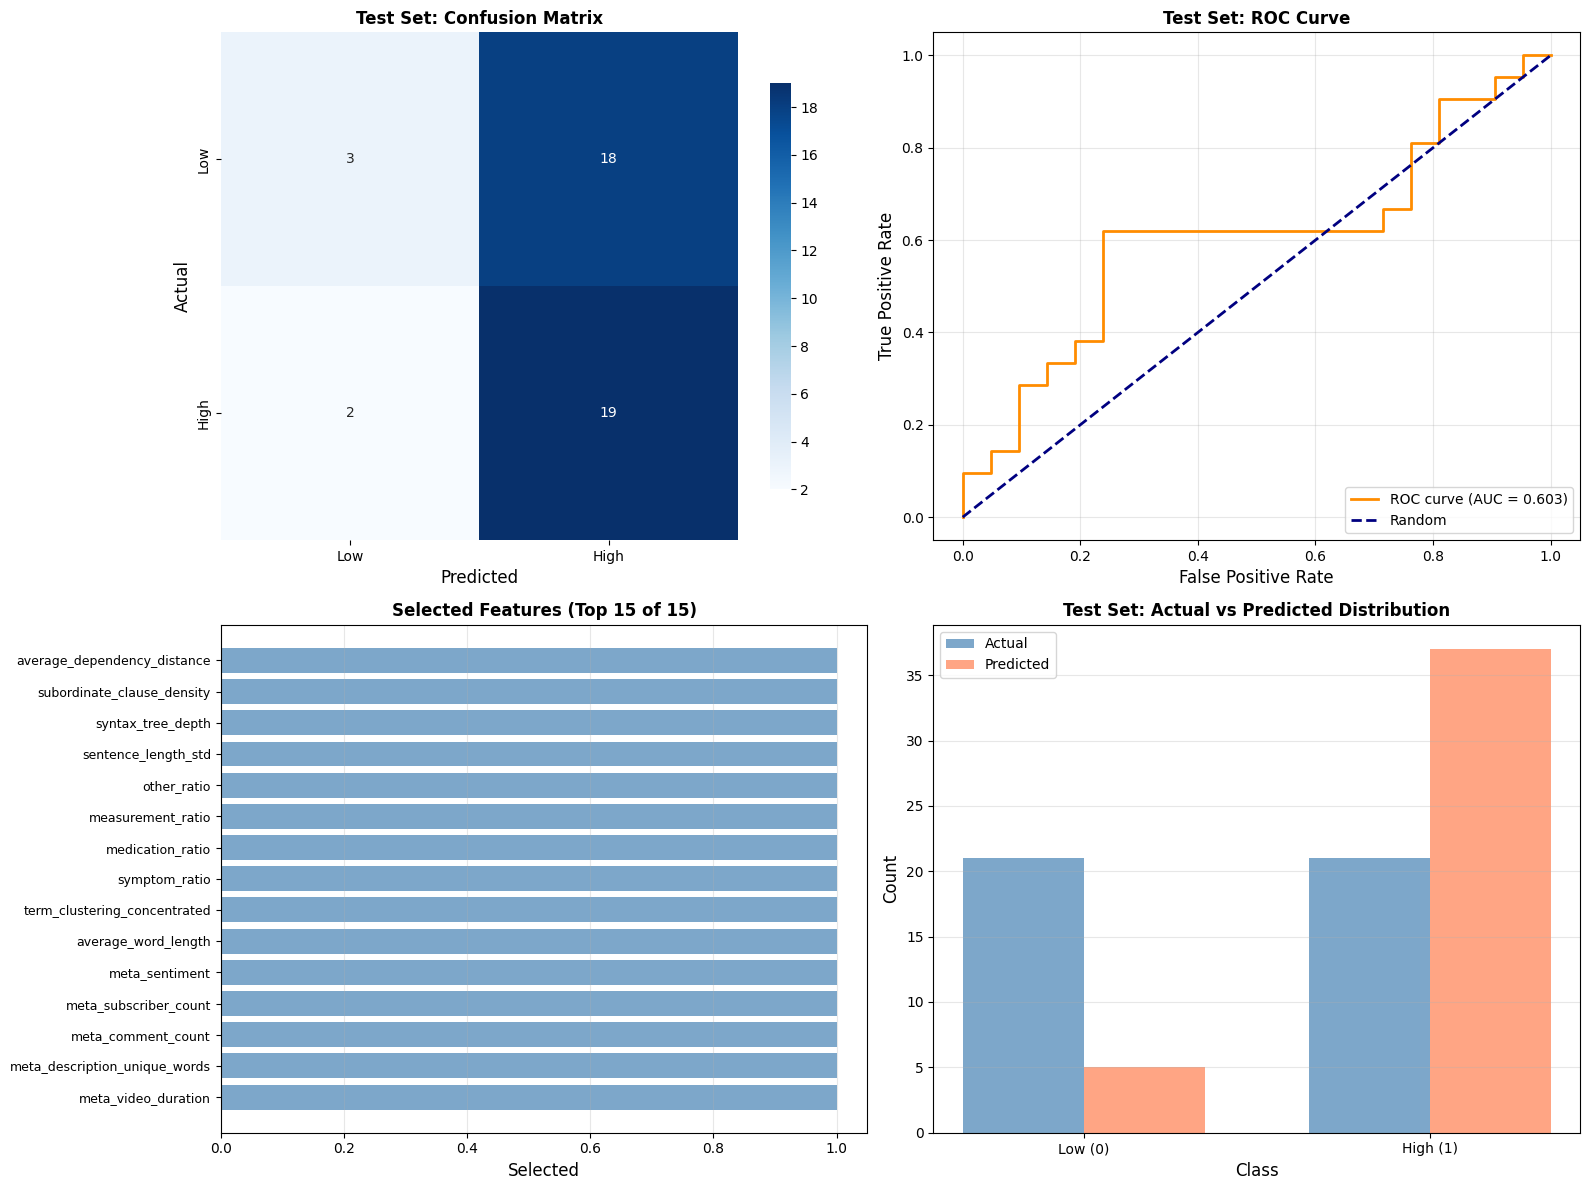


📋 All Selected Features (15):
    1. meta_video_duration
    2. meta_description_unique_words
    3. meta_comment_count
    4. meta_subscriber_count
    5. meta_sentiment
    6. average_word_length
    7. term_clustering_concentrated
    8. symptom_ratio
    9. medication_ratio
   10. measurement_ratio
   11. other_ratio
   12. sentence_length_std
   13. syntax_tree_depth
   14. subordinate_clause_density
   15. average_dependency_distance



In [33]:
# ============================================================================
# VISUALIZATION AND DETAILED ANALYSIS
# ============================================================================

print("=" * 80)
print("VISUALIZATION AND DETAILED ANALYSIS")
print("=" * 80)

# Use evaluation results from evaluate_regression_as_classification
# (This should have been computed in Cell 8)
if 'eval_test' not in locals():
    print("⚠️  Evaluation results not found. Computing now...")
    eval_test = evaluate_regression_as_classification(y_test, y_test_pred, threshold)
    eval_train = evaluate_regression_as_classification(y_train, y_train_pred, threshold)

# Confusion Matrix (use binary predictions from evaluation function)
cm_test = eval_test['confusion_matrix']

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(eval_test['y_true_binary'], eval_test['y_pred_binary'], target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if eval_test['y_pred_proba'] is not None and eval_test['classification_metrics']['auc'] is not None:
    fpr, tpr, _ = roc_curve(eval_test['y_true_binary'], eval_test['y_pred_proba'])
    roc_auc = eval_test['classification_metrics']['auc']
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features (Top 15)
ax3 = axes[1, 0]
if len(selected_features) > 0:
    features_to_show = selected_features[:15] if len(selected_features) > 15 else selected_features
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='steelblue', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Prediction Distribution
ax4 = axes[1, 1]
unique_actual, counts_actual = np.unique(eval_test['y_true_binary'], return_counts=True)
x_pos = np.arange(len(unique_actual))
width = 0.35
ax4.bar(x_pos - width/2, counts_actual, width, label='Actual', color='steelblue', alpha=0.7)
pred_counts = np.zeros(len(unique_actual))
for i, cls in enumerate(unique_actual):
    pred_counts[i] = np.sum(eval_test['y_pred_binary'] == cls)
ax4.bar(x_pos + width/2, pred_counts, width, label='Predicted', color='coral', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['Low (0)', 'High (1)'], fontsize=10)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_xlabel('Class', fontsize=12)
ax4.set_title('Test Set: Actual vs Predicted Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features)}):")
print("=" * 80)
for i, feat in enumerate(selected_features, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


## Decision Tree

In [ ]:
# ============================================================================
# DECISION TREE: Feature Selection + Hyperparameter Tuning (Anti-Overfitting)
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# Focus on preventing overfitting with max_depth, min_samples_split, etc.
# ============================================================================

print("=" * 80)
print("DECISION TREE: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Create pipeline with feature selection and Decision Tree Regressor
dt_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_regression)),
    ('regression', DecisionTreeRegressor(random_state=42))
])

# Parameter grid for optimization (focus on preventing overfitting)
param_grid_dt = {
    'feature_selection__k': [5, 10, 15, 20, 25, 30],
    'regression__max_depth': [3, 5, 7, 10, 15, 20, None],  # Limit depth to prevent overfitting
    'regression__min_samples_split': [2, 5, 10, 20, 30, 50],  # Minimum samples to split
    'regression__min_samples_leaf': [1, 2, 4, 5, 10, 15, 20],  # Minimum samples in leaf
    'regression__max_features': ['sqrt', 'log2', None, 0.5, 0.7],  # Limit features per split
    'regression__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],  # Splitting criterion for regression
    'regression__min_impurity_decrease': [0.0, 0.001, 0.01, 0.1]  # Minimum impurity decrease
}

# K-Fold for cross-validation (regression, not stratified)
cv_dt = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations_dt = (len(param_grid_dt['feature_selection__k']) * 
                         len(param_grid_dt['regression__max_depth']) * 
                         len(param_grid_dt['regression__min_samples_split']) *
                         len(param_grid_dt['regression__min_samples_leaf']) *
                         len(param_grid_dt['regression__max_features']) *
                         len(param_grid_dt['regression__criterion']) *
                         len(param_grid_dt['regression__min_impurity_decrease']))

print(f"\n🚀 Starting GridSearchCV optimization for Decision Tree...")
print(f"   Feature selection k values: {len(param_grid_dt['feature_selection__k'])} options")
print(f"   Max depth: {len(param_grid_dt['regression__max_depth'])} options (including None)")
print(f"   Min samples split: {len(param_grid_dt['regression__min_samples_split'])} options")
print(f"   Min samples leaf: {len(param_grid_dt['regression__min_samples_leaf'])} options")
print(f"   Max features: {len(param_grid_dt['regression__max_features'])} options")
print(f"   Criterion: {len(param_grid_dt['regression__criterion'])} options")
print(f"   Min impurity decrease: {len(param_grid_dt['regression__min_impurity_decrease'])} options")
print(f"   Total parameter combinations: {total_combinations_dt}")
print(f"   With 5-fold CV: {total_combinations_dt * 5} model fits")
print("=" * 80)

# Grid search
grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=cv_dt,
    scoring='r2',  # Use R² for regression
    n_jobs=-1,  # Use all available CPUs
    verbose=1
)

# Fit grid search (use continuous y)
grid_search_dt.fit(X_train, y_train)

# Get best parameters from GridSearchCV
best_params_dt = grid_search_dt.best_params_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and CV score
print(f"\n🏆 Best Parameters (from GridSearchCV):")
for param, value in best_params_dt.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score (R²): {grid_search_dt.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features: {X_train.shape[1]}")

# Create a new pipeline with best parameters
best_pipeline_dt = Pipeline([
    ('feature_selection', SelectKBest(f_regression, k=best_params_dt['feature_selection__k'])),
    ('regression', DecisionTreeRegressor(
        max_depth=best_params_dt['regression__max_depth'],
        min_samples_split=best_params_dt['regression__min_samples_split'],
        min_samples_leaf=best_params_dt['regression__min_samples_leaf'],
        max_features=best_params_dt['regression__max_features'],
        criterion=best_params_dt['regression__criterion'],
        min_impurity_decrease=best_params_dt['regression__min_impurity_decrease'],
        random_state=42
    ))
])

# Retrain on FULL training set (use continuous y)
best_pipeline_dt.fit(X_train, y_train)

# Use this as the final model
best_model_dt = best_pipeline_dt

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# Get selected features
selected_features_mask_dt = best_model_dt.named_steps['feature_selection'].get_support()
selected_features_dt = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask_dt[i]]
n_selected_features_dt = len(selected_features_dt)

print(f"\n📋 Selected Features: {n_selected_features_dt} out of {len(feature_names)}")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print(f"\n📊 Test Set Information:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_test.shape[1]}")

# Display tree complexity info
best_dt = best_model_dt.named_steps['regression']
print(f"\n🌳 Tree Complexity:")
print(f"   Max depth: {best_dt.max_depth if best_dt.max_depth else 'Unlimited'}")
print(f"   Min samples split: {best_dt.min_samples_split}")
print(f"   Min samples leaf: {best_dt.min_samples_leaf}")
print(f"   Max features: {best_dt.max_features}")
print(f"   Number of leaves: {best_dt.get_n_leaves()}")
print(f"   Tree depth: {best_dt.get_depth()}")

print("=" * 80)

# ============================================================================
# FINAL EVALUATION: Make predictions on test set
# ============================================================================
print("\n🔍 Making predictions on test set with retrained model...")

# Make predictions (continuous values)
y_train_pred_dt = best_model_dt.predict(X_train)
y_test_pred_dt = best_model_dt.predict(X_test)

print("✅ Predictions completed!")
print(f"   Training predictions: {len(y_train_pred_dt)} samples")
print(f"   Test predictions: {len(y_test_pred_dt)} samples")

# Evaluate as regression
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)
train_rmse_dt = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
test_rmse_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)

# Evaluate as classification (using threshold)
eval_train_dt = evaluate_regression_as_classification(y_train, y_train_pred_dt, threshold)
eval_test_dt = evaluate_regression_as_classification(y_test, y_test_pred_dt, threshold)

# Check for overfitting (difference between train and test R²)
overfitting_gap_r2_dt = train_r2_dt - test_r2_dt
overfitting_gap_acc_dt = eval_train_dt['classification_metrics']['accuracy'] - eval_test_dt['classification_metrics']['accuracy']

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 REGRESSION Performance (Training Set):")
print(f"   R²:   {train_r2_dt:.4f}")
print(f"   RMSE: {train_rmse_dt:.4f}")
print(f"   MAE:  {train_mae_dt:.4f}")

print(f"\n📊 REGRESSION Performance (Test Set - FINAL EVALUATION):")
print(f"   ✅ Final Test R²:   {test_r2_dt:.4f}")
print(f"   ✅ Final Test RMSE: {test_rmse_dt:.4f}")
print(f"   ✅ Final Test MAE:  {test_mae_dt:.4f}")

print(f"\n📊 CLASSIFICATION Performance (at threshold={threshold}):")
print(f"\n   Training Set:")
print(f"   Accuracy:  {eval_train_dt['classification_metrics']['accuracy']:.4f}")
print(f"   Precision: {eval_train_dt['classification_metrics']['precision']:.4f}")
print(f"   Recall:    {eval_train_dt['classification_metrics']['recall']:.4f}")
print(f"   F1 Score:  {eval_train_dt['classification_metrics']['f1']:.4f}")
if eval_train_dt['classification_metrics']['auc'] is not None:
    print(f"   AUC-ROC:   {eval_train_dt['classification_metrics']['auc']:.4f}")

print(f"\n   Test Set (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {eval_test_dt['classification_metrics']['accuracy']:.4f}")
print(f"   ✅ Final Test Precision: {eval_test_dt['classification_metrics']['precision']:.4f}")
print(f"   ✅ Final Test Recall:    {eval_test_dt['classification_metrics']['recall']:.4f}")
print(f"   ✅ Final Test F1 Score:  {eval_test_dt['classification_metrics']['f1']:.4f}")
if eval_test_dt['classification_metrics']['auc'] is not None:
    print(f"   ✅ Final Test AUC-ROC:   {eval_test_dt['classification_metrics']['auc']:.4f}")

print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print(f"\n⚠️  Overfitting Check:")
print(f"   Train-Test R² Gap: {overfitting_gap_r2_dt:.4f}")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_acc_dt:.4f}")
if overfitting_gap_r2_dt > 0.15 or overfitting_gap_acc_dt > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
elif overfitting_gap_r2_dt > 0.10 or overfitting_gap_acc_dt > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
else:
    print(f"   ✅ Good: Gap is acceptable.")

print("\n" + "=" * 80)


DECISION TREE: Feature Selection + Hyperparameter Tuning

🚀 Starting GridSearchCV optimization for Decision Tree...
   Feature selection k values: 6 options
   Max depth: 7 options (including None)
   Min samples split: 6 options
   Min samples leaf: 7 options
   Max features: 5 options
   Criterion: 3 options
   Min impurity decrease: 4 options
   Total parameter combinations: 105840
   With 5-fold CV: 529200 model fits
Fitting 5 folds for each of 105840 candidates, totalling 529200 fits

OPTIMIZATION COMPLETE!

🏆 Best Parameters (from GridSearchCV):
   feature_selection__k: 10
   regression__criterion: absolute_error
   regression__max_depth: 3
   regression__max_features: sqrt
   regression__min_impurity_decrease: 0.001
   regression__min_samples_leaf: 20
   regression__min_samples_split: 2

📊 Best CV Score (R²): -0.0012

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL training set with best parameters...
   Training samples: 140
   Features: 31
✅ Mo

DECISION TREE: Visualization and Detailed Analysis

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.55      0.29      0.38        21
        High       0.52      0.76      0.62        21

    accuracy                           0.52        42
   macro avg       0.53      0.52      0.50        42
weighted avg       0.53      0.52      0.50        42



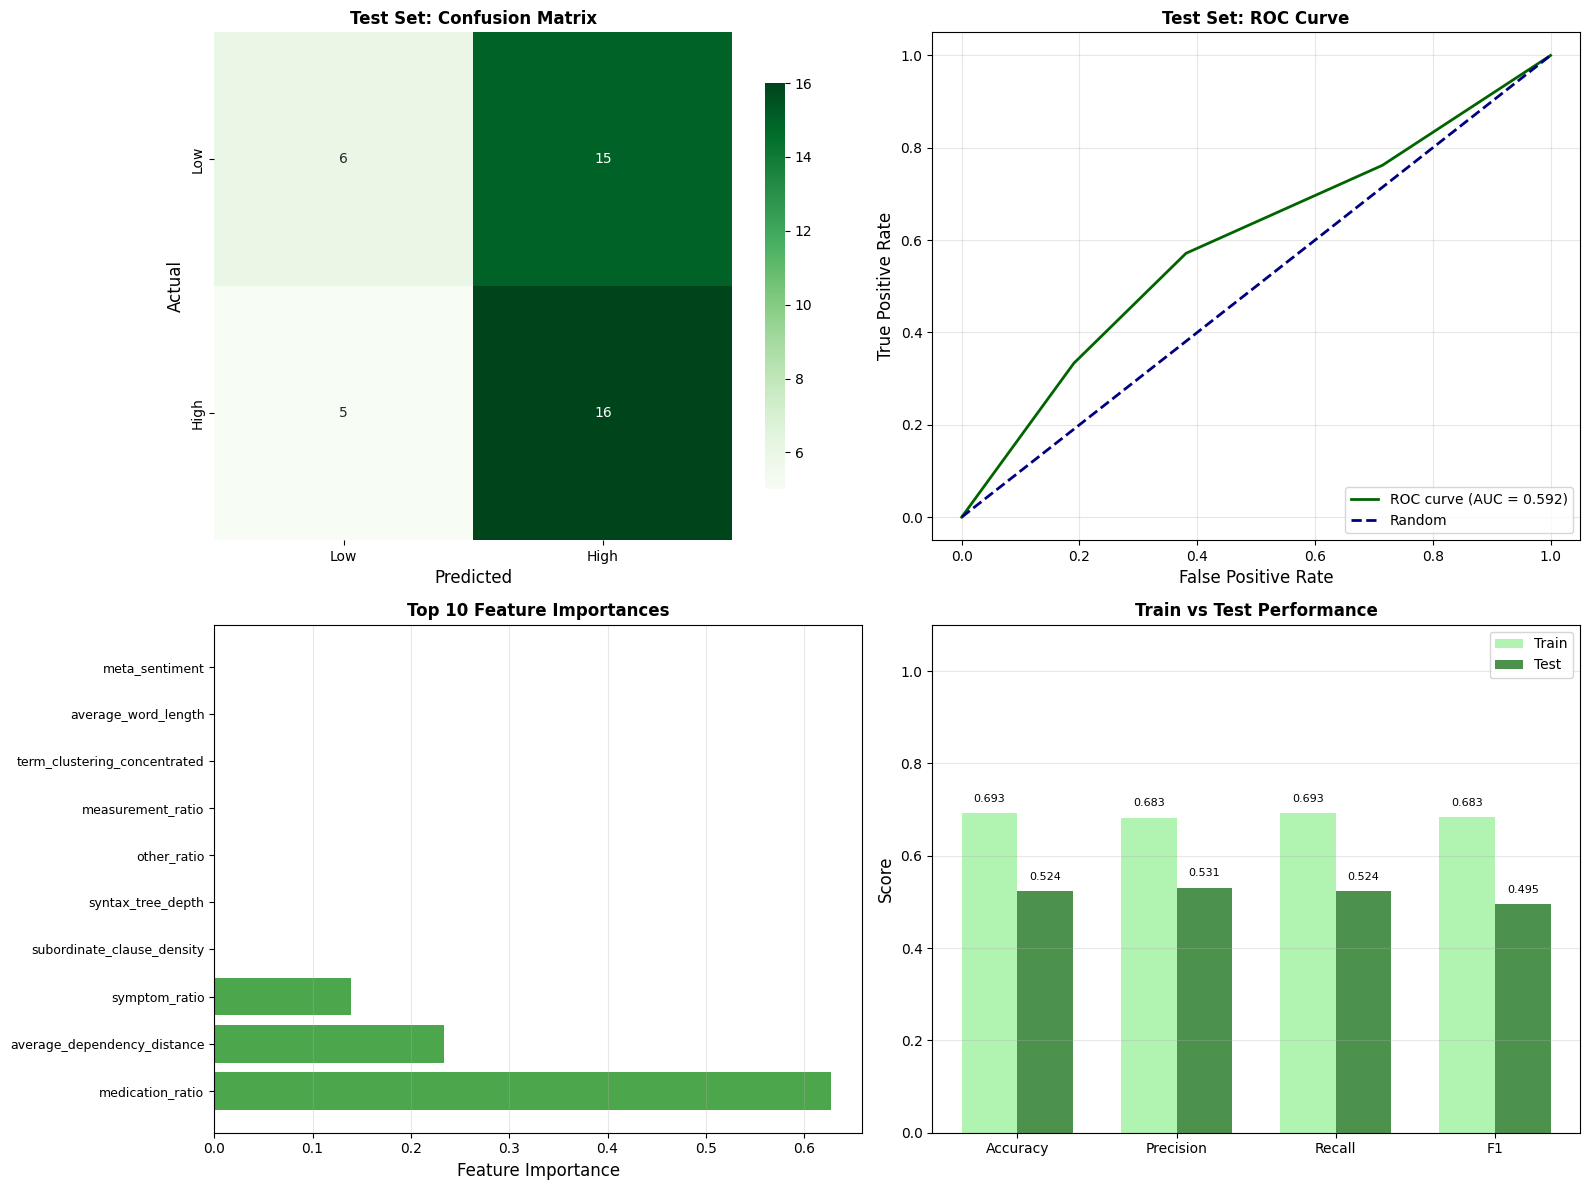


📋 All Selected Features (10):
    1. meta_sentiment
    2. average_word_length
    3. term_clustering_concentrated
    4. symptom_ratio
    5. medication_ratio
    6. measurement_ratio
    7. other_ratio
    8. syntax_tree_depth
    9. subordinate_clause_density
   10. average_dependency_distance

📊 Feature Importance (Top 10):
    1. medication_ratio                         : 0.6274
    2. average_dependency_distance              : 0.2340
    3. symptom_ratio                            : 0.1386
    4. meta_sentiment                           : 0.0000
    5. average_word_length                      : 0.0000
    6. term_clustering_concentrated             : 0.0000
    7. measurement_ratio                        : 0.0000
    8. other_ratio                              : 0.0000
    9. syntax_tree_depth                        : 0.0000
   10. subordinate_clause_density               : 0.0000



In [ ]:
# ============================================================================
# DECISION TREE: Visualization and Detailed Analysis
# ============================================================================

print("=" * 80)
print("DECISION TREE: Visualization and Detailed Analysis")
print("=" * 80)

# Confusion Matrix (use binary predictions from evaluation function)
cm_test_dt = eval_test_dt['confusion_matrix']

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(eval_test_dt['y_true_binary'], eval_test_dt['y_pred_binary'], target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test_dt, annot=True, fmt='d', cmap='Greens', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if eval_test_dt['y_pred_proba'] is not None and eval_test_dt['classification_metrics']['auc'] is not None:
    fpr_dt, tpr_dt, _ = roc_curve(eval_test_dt['y_true_binary'], eval_test_dt['y_pred_proba'])
    roc_auc_dt = eval_test_dt['classification_metrics']['auc']
    ax2.plot(fpr_dt, tpr_dt, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Feature Importance (Top 15)
ax3 = axes[1, 0]
best_dt = best_model_dt.named_steps['regression']
feature_importance = best_dt.feature_importances_
# Get indices of selected features
selected_indices = [i for i in range(len(feature_names)) if selected_features_mask_dt[i]]
selected_importance = feature_importance
selected_feature_names_dt = selected_features_dt

# Sort by importance
importance_sorted_idx = np.argsort(selected_importance)[::-1]
top_n = min(15, len(selected_feature_names_dt))
top_indices = importance_sorted_idx[:top_n]

ax3.barh(range(top_n), selected_importance[top_indices], color='green', alpha=0.7)
ax3.set_yticks(range(top_n))
ax3.set_yticklabels([selected_feature_names_dt[i][:30] for i in top_indices], fontsize=9)
ax3.set_xlabel('Feature Importance', fontsize=12)
ax3.set_title(f'Top {top_n} Feature Importances', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Train vs Test Performance Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_metrics = [
    eval_train_dt['classification_metrics']['accuracy'],
    eval_train_dt['classification_metrics']['precision'],
    eval_train_dt['classification_metrics']['recall'],
    eval_train_dt['classification_metrics']['f1']
]
test_metrics = [
    eval_test_dt['classification_metrics']['accuracy'],
    eval_test_dt['classification_metrics']['precision'],
    eval_test_dt['classification_metrics']['recall'],
    eval_test_dt['classification_metrics']['f1']
]

x_pos = np.arange(len(metrics))
width = 0.35
ax4.bar(x_pos - width/2, train_metrics, width, label='Train', color='lightgreen', alpha=0.7)
ax4.bar(x_pos + width/2, test_metrics, width, label='Test', color='darkgreen', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_metrics, test_metrics)):
    ax4.text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    ax4.text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features_dt)}):")
print("=" * 80)
for i, feat in enumerate(selected_features_dt, 1):
    print(f"   {i:2d}. {feat}")

# Display feature importance (sorted)
print(f"\n📊 Feature Importance (Top 10):")
print("=" * 80)
importance_sorted = sorted(zip(selected_feature_names_dt, selected_importance), 
                           key=lambda x: x[1], reverse=True)
for i, (feat, imp) in enumerate(importance_sorted[:10], 1):
    print(f"   {i:2d}. {feat[:40]:40s} : {imp:.4f}")

print("\n" + "=" * 80)


In [38]:
# ============================================================================
# SAVE DECISION TREE MODEL AND RESULTS
# ============================================================================

import pickle
import json
from datetime import datetime

print("=" * 80)
print("SAVING DECISION TREE MODEL AND RESULTS")
print("=" * 80)

# Verify that best_model_dt is the retrained model (not from GridSearchCV)
# best_model_dt should be trained on FULL training set with best parameters
print("\n🔍 Verifying model to save...")
if hasattr(best_model_dt, 'named_steps'):
    print("✅ Model is a Pipeline (retrained model)")
    print(f"   Model type: {type(best_model_dt).__name__}")
    print(f"   This model was trained on FULL training set ({X_train.shape[0]} samples)")
else:
    print("⚠️  WARNING: Model structure unexpected")

# Save best model (this is the model retrained on FULL training set)
model_filename_dt = "data/best_decision_tree_model.pkl"
with open(model_filename_dt, 'wb') as f:
    pickle.dump(best_model_dt, f)
print(f"\n✅ Best Decision Tree model saved to: {model_filename_dt}")
print(f"   📝 Note: This model was trained on FULL training set with best parameters")

# Get tree complexity info
best_dt = best_model_dt.named_steps['regression']

# Ensure best_params_dt exists (in case this cell is run independently)
if 'best_params_dt' not in locals():
    # Try to get from grid_search_dt if available
    try:
        best_params_dt = grid_search_dt.best_params_
        print("⚠️  Note: Using best_params from grid_search_dt (retraining cell may not have been run)")
    except NameError:
        print("⚠️  ERROR: best_params_dt not found. Please run the Decision Tree training cell first!")
        raise

# Save model metadata
metadata_dt = {
    'model_name': 'Decision Tree Regressor with Feature Selection',
    'problem_type': 'regression_with_classification_evaluation',
    'threshold': 0.8,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_selected_features': len(selected_features_dt),
    'selected_features': selected_features_dt,
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0],
    'best_parameters': best_params_dt,
    'training_note': 'Model was retrained on FULL training set with best parameters from GridSearchCV',
    'best_cv_score': float(grid_search_dt.best_score_),
    'tree_complexity': {
        'max_depth': best_dt.max_depth if best_dt.max_depth else 'Unlimited',
        'min_samples_split': int(best_dt.min_samples_split),
        'min_samples_leaf': int(best_dt.min_samples_leaf),
        'max_features': str(best_dt.max_features),
        'n_leaves': int(best_dt.get_n_leaves()),
        'tree_depth': int(best_dt.get_depth()),
        'criterion': best_dt.criterion
    },
    'regression_metrics': {
        'train_r2': float(train_r2_dt),
        'test_r2': float(test_r2_dt),
        'train_rmse': float(train_rmse_dt),
        'test_rmse': float(test_rmse_dt),
        'train_mae': float(train_mae_dt),
        'test_mae': float(test_mae_dt),
        'overfitting_gap_r2': float(overfitting_gap_r2_dt)
    },
    'classification_metrics': {
        'train_accuracy': float(eval_train_dt['classification_metrics']['accuracy']),
        'test_accuracy': float(eval_test_dt['classification_metrics']['accuracy']),
        'train_precision': float(eval_train_dt['classification_metrics']['precision']),
        'test_precision': float(eval_test_dt['classification_metrics']['precision']),
        'train_recall': float(eval_train_dt['classification_metrics']['recall']),
        'test_recall': float(eval_test_dt['classification_metrics']['recall']),
        'train_f1': float(eval_train_dt['classification_metrics']['f1']),
        'test_f1': float(eval_test_dt['classification_metrics']['f1']),
        'overfitting_gap_acc': float(overfitting_gap_acc_dt)
    }
}

if eval_train_dt['classification_metrics']['auc'] is not None:
    metadata_dt['classification_metrics']['train_auc'] = float(eval_train_dt['classification_metrics']['auc'])
if eval_test_dt['classification_metrics']['auc'] is not None:
    metadata_dt['classification_metrics']['test_auc'] = float(eval_test_dt['classification_metrics']['auc'])

# Add feature importance (if available)
# Ensure variables exist
if 'selected_feature_names_dt' not in locals() or 'selected_importance' not in locals():
    # Get from the model if not already defined
    best_dt = best_model_dt.named_steps['regression']
    selected_importance = best_dt.feature_importances_
    selected_feature_names_dt = selected_features_dt

if len(selected_feature_names_dt) == len(selected_importance):
    feature_importance_dict = {feat: float(imp) for feat, imp in zip(selected_feature_names_dt, selected_importance)}
    metadata_dt['feature_importance'] = feature_importance_dict
else:
    print("⚠️  Warning: Feature importance arrays length mismatch, skipping feature importance in metadata")

metadata_filename_dt = "data/best_decision_tree_metadata.json"
with open(metadata_filename_dt, 'w') as f:
    json.dump(metadata_dt, f, indent=2)
print(f"✅ Decision Tree model metadata saved to: {metadata_filename_dt}")

# Save selected features with importance
selected_features_df_dt = pd.DataFrame({
    'feature_name': selected_feature_names_dt,
    'importance': selected_importance,
    'rank': range(1, len(selected_feature_names_dt) + 1)
})
selected_features_df_dt = selected_features_df_dt.sort_values('importance', ascending=False).reset_index(drop=True)
selected_features_df_dt['rank'] = range(1, len(selected_features_df_dt) + 1)
selected_features_df_dt.to_csv('data/decision_tree_selected_features.csv', index=False)
print(f"✅ Selected features with importance saved to: data/decision_tree_selected_features.csv")

print("\n" + "=" * 80)
print("DECISION TREE MODEL SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Model file: {model_filename_dt}")
print(f"   • Metadata file: {metadata_filename_dt}")
print(f"   • Selected features: data/decision_tree_selected_features.csv")
print(f"   • Tree depth: {best_dt.get_depth()}")
print(f"   • Number of leaves: {best_dt.get_n_leaves()}")
print(f"   • Overfitting gap (R²): {overfitting_gap_r2_dt:.4f}")
print(f"   • Overfitting gap (Accuracy): {overfitting_gap_acc_dt:.4f}")
print("\n💡 To load the model later:")
print(f"   import pickle")
print(f"   with open('{model_filename_dt}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print("=" * 80)


SAVING DECISION TREE MODEL AND RESULTS

🔍 Verifying model to save...
✅ Model is a Pipeline (retrained model)
   Model type: Pipeline
   This model was trained on FULL training set (140 samples)

✅ Best Decision Tree model saved to: data/best_decision_tree_model.pkl
   📝 Note: This model was trained on FULL training set with best parameters
✅ Decision Tree model metadata saved to: data/best_decision_tree_metadata.json
✅ Selected features with importance saved to: data/decision_tree_selected_features.csv

DECISION TREE MODEL SAVED SUCCESSFULLY!

📝 Summary:
   • Model file: data/best_decision_tree_model.pkl
   • Metadata file: data/best_decision_tree_metadata.json
   • Selected features: data/decision_tree_selected_features.csv
   • Tree depth: 3
   • Number of leaves: 4
   • Overfitting gap (R²): 0.2223
   • Overfitting gap (Accuracy): 0.1690

💡 To load the model later:
   import pickle
   with open('data/best_decision_tree_model.pkl', 'rb') as f:
       model = pickle.load(f)


## SVM

In [ ]:
# ============================================================================
# SVM: Feature Selection + Hyperparameter Tuning (Anti-Overfitting)
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# Focus on preventing overfitting with different kernels and regularization
# ============================================================================

print("=" * 80)
print("SVM: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Note: Need to prepare data first (run Cell 3 before this)
# Check if data is prepared
try:
    X_train_check = X_train
    y_train_check = y_train_binary_aligned
    print("✅ Data is prepared. Proceeding with SVM optimization...")
except NameError:
    print("⚠️  WARNING: Data not prepared yet. Please run Cell 3 (DATA PREPARATION) first!")
    print("   This cell will be skipped.")
    raise

# Create pipeline with feature selection and SVR (Support Vector Regression)
svm_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_regression)),
    ('regression', SVR())
])

# Parameter grid for optimization (focus on preventing overfitting)
# Different kernels have different parameters
# NOTE: Reduced grid size for faster execution (still comprehensive)
param_grid_svm = {
    'feature_selection__k': [5, 10, 12, 15, 18, 20],
    'regression__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'regression__C': [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0, 2.0],  # Regularization parameter
    'regression__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # For rbf, poly, sigmoid
    'regression__degree': [1, 2, 3, 4],  # For poly kernel only
    'regression__coef0': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],  # For poly and sigmoid
    'regression__epsilon': [0.01, 0.1, 0.2, 0.5],  # Epsilon-tube for SVR
    'regression__shrinking': [True, False]  # Shrinking heuristic
}




# Stratified K-Fold for cross-validation
cv_svm = KFold(n_splits=5, shuffle=True, random_state=42)  # KFold for regression

# Grid search
print("\n📊 Starting optimization...")
print("   (This may take a while. Progress will be shown below.)\n")

start_time_svm = time.time()

grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=cv_svm,
    scoring='r2',  # Use R² for regression
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
    return_train_score=True  # Return training scores for overfitting check
)

# Fit grid search (use continuous y)
grid_search_svm.fit(X_train, y_train)

elapsed_time_svm = time.time() - start_time_svm

print(f"\n✅ Optimization completed!")
print(f"   Total time: {elapsed_time_svm/60:.1f} minutes ({elapsed_time_svm:.1f} seconds)")

# Get best parameters from GridSearchCV
best_params_svm = grid_search_svm.best_params_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and CV score
print(f"\n🏆 Best Parameters (from GridSearchCV):")
for param, value in best_params_svm.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search_svm.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features: {X_train.shape[1]}")

# Create a new pipeline with best parameters
best_pipeline_svm = Pipeline([
    ('feature_selection', SelectKBest(f_regression, k=best_params_svm['feature_selection__k'])),
    ('regression', SVR(
        kernel=best_params_svm['regression__kernel'],
        C=best_params_svm['regression__C'],
        gamma=best_params_svm['regression__gamma'],
        degree=best_params_svm.get('regression__degree', 3),  # Default for non-poly kernels
        coef0=best_params_svm.get('regression__coef0', 0.0),  # Default for linear/rbf
        epsilon=best_params_svm.get('regression__epsilon', 0.1),  # Epsilon-tube
        shrinking=best_params_svm['regression__shrinking']
    ))
])

# Retrain on FULL training set (use continuous y)
best_pipeline_svm.fit(X_train, y_train)

# Use this as the final model
best_model_svm = best_pipeline_svm

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print(f"\n📊 Test Set Information:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_test.shape[1]}")

# Get selected features
selected_features_mask_svm = best_model_svm.named_steps['feature_selection'].get_support()
selected_features_svm = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask_svm[i]]
n_selected_features_svm = len(selected_features_svm)

print(f"\n📋 Selected Features: {n_selected_features_svm} out of {len(feature_names)}")

# Display SVR info
best_svm = best_model_svm.named_steps['regression']
print(f"\n🔧 SVR Configuration:")
print(f"   Kernel: {best_svm.kernel}")
print(f"   C (regularization): {best_svm.C}")
print(f"   Gamma: {best_svm.gamma}")
if best_svm.kernel == 'poly':
    print(f"   Degree: {best_svm.degree}")
    print(f"   Coef0: {best_svm.coef0}")
elif best_svm.kernel == 'sigmoid':
    print(f"   Coef0: {best_svm.coef0}")
print(f"   Epsilon: {best_svm.epsilon}")
print(f"   Shrinking: {best_svm.shrinking}")

print("=" * 80)

# ============================================================================
# FINAL EVALUATION: Make predictions on test set
# ============================================================================
print("\n🔍 Making predictions on test set with retrained model...")

# Make predictions (continuous values)
y_train_pred_svm = best_model_svm.predict(X_train)
y_test_pred_svm = best_model_svm.predict(X_test)

print("✅ Predictions completed!")
print(f"   Training predictions: {len(y_train_pred_svm)} samples")
print(f"   Test predictions: {len(y_test_pred_svm)} samples")

# Evaluate as regression
train_r2_svm = r2_score(y_train, y_train_pred_svm)
test_r2_svm = r2_score(y_test, y_test_pred_svm)
train_rmse_svm = np.sqrt(mean_squared_error(y_train, y_train_pred_svm))
test_rmse_svm = np.sqrt(mean_squared_error(y_test, y_test_pred_svm))
train_mae_svm = mean_absolute_error(y_train, y_train_pred_svm)
test_mae_svm = mean_absolute_error(y_test, y_test_pred_svm)

# Evaluate as classification (using threshold)
eval_train_svm = evaluate_regression_as_classification(y_train, y_train_pred_svm, threshold)
eval_test_svm = evaluate_regression_as_classification(y_test, y_test_pred_svm, threshold)

# Check for overfitting (difference between train and test R²)
overfitting_gap_r2_svm = train_r2_svm - test_r2_svm
overfitting_gap_acc_svm = eval_train_svm['classification_metrics']['accuracy'] - eval_test_svm['classification_metrics']['accuracy']

# Check train vs test scores from CV
if 'mean_train_score' in grid_search_svm.cv_results_:
    mean_train_scores = grid_search_svm.cv_results_['mean_train_score']
    mean_test_scores = grid_search_svm.cv_results_['mean_test_score']
    best_idx = grid_search_svm.best_index_
    cv_train_score = mean_train_scores[best_idx]
    cv_test_score = mean_test_scores[best_idx]
    cv_overfitting_gap = cv_train_score - cv_test_score
else:
    cv_train_score = None
    cv_test_score = None
    cv_overfitting_gap = None

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Cross-Validation Performance:")
print(f"   Train CV Score: {cv_train_score:.4f}" if cv_train_score is not None else "   Train CV Score: N/A")
print(f"   Test CV Score: {grid_search_svm.best_score_:.4f}")
if cv_overfitting_gap is not None:
    print(f"   CV Overfitting Gap: {cv_overfitting_gap:.4f}")
    if cv_overfitting_gap > 0.15:
        print(f"   ⚠️  WARNING: Large CV gap detected! Model may be overfitting.")
    elif cv_overfitting_gap > 0.10:
        print(f"   ⚠️  CAUTION: Moderate CV gap detected.")
    else:
        print(f"   ✅ Good: CV gap is acceptable.")

print(f"\n📊 REGRESSION Performance (Training Set):")
print(f"   R²:   {train_r2_svm:.4f}")
print(f"   RMSE: {train_rmse_svm:.4f}")
print(f"   MAE:  {train_mae_svm:.4f}")

print(f"\n📊 REGRESSION Performance (Test Set - FINAL EVALUATION):")
print(f"   ✅ Final Test R²:   {test_r2_svm:.4f}")
print(f"   ✅ Final Test RMSE: {test_rmse_svm:.4f}")
print(f"   ✅ Final Test MAE:  {test_mae_svm:.4f}")

print(f"\n📊 CLASSIFICATION Performance (at threshold={threshold}):")
print(f"\n   Training Set:")
print(f"   Accuracy:  {eval_train_svm['classification_metrics']['accuracy']:.4f}")
print(f"   Precision: {eval_train_svm['classification_metrics']['precision']:.4f}")
print(f"   Recall:    {eval_train_svm['classification_metrics']['recall']:.4f}")
print(f"   F1 Score:  {eval_train_svm['classification_metrics']['f1']:.4f}")
if eval_train_svm['classification_metrics']['auc'] is not None:
    print(f"   AUC-ROC:   {eval_train_svm['classification_metrics']['auc']:.4f}")

print(f"\n   Test Set (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {eval_test_svm['classification_metrics']['accuracy']:.4f}")
print(f"   ✅ Final Test Precision: {eval_test_svm['classification_metrics']['precision']:.4f}")
print(f"   ✅ Final Test Recall:    {eval_test_svm['classification_metrics']['recall']:.4f}")
print(f"   ✅ Final Test F1 Score:  {eval_test_svm['classification_metrics']['f1']:.4f}")
if eval_test_svm['classification_metrics']['auc'] is not None:
    print(f"   ✅ Final Test AUC-ROC:   {eval_test_svm['classification_metrics']['auc']:.4f}")
print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print(f"\n⚠️  Overfitting Check (Train vs Test):")
print(f"   Train-Test R² Gap: {overfitting_gap_r2_svm:.4f}")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_acc_svm:.4f}")
if overfitting_gap_r2_svm > 0.15 or overfitting_gap_acc_svm > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    print(f"   💡 Consider increasing C (regularization) or adjusting kernel parameters to reduce overfitting.")
elif overfitting_gap_r2_svm > 0.10 or overfitting_gap_acc_svm > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
    print(f"   💡 Consider slightly increasing C if gap increases.")
else:
    print(f"   ✅ Good: Gap is acceptable.")

print("\n" + "=" * 80)


SVM: Feature Selection + Hyperparameter Tuning
✅ Data is prepared. Proceeding with SVM optimization...

📊 Starting optimization...
   (This may take a while. Progress will be shown below.)

Fitting 5 folds for each of 258048 candidates, totalling 1290240 fits

✅ Optimization completed!
   Total time: 13.5 minutes (812.7 seconds)

OPTIMIZATION COMPLETE!

🏆 Best Parameters (from GridSearchCV):
   feature_selection__k: 20
   regression__C: 0.05
   regression__coef0: 0.0
   regression__degree: 3
   regression__epsilon: 0.1
   regression__gamma: scale
   regression__kernel: poly
   regression__shrinking: True

📊 Best CV Score: 0.0295

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL training set with best parameters...
   Training samples: 140
   Features: 31
✅ Model retrained on FULL training set!

EVALUATING ON TEST SET

📊 Test Set Information:
   Test samples: 42
   Features: 31

📋 Selected Features: 20 out of 31

🔧 SVR Configuration:
   Kernel: poly
   C 

NameError: name 'train_acc_svm' is not defined

SVM: Visualization and Detailed Analysis

📊 Classification Report (Test Set):
              precision    recall  f1-score   support

         Low       0.25      0.05      0.08        21
        High       0.47      0.86      0.61        21

    accuracy                           0.45        42
   macro avg       0.36      0.45      0.35        42
weighted avg       0.36      0.45      0.35        42



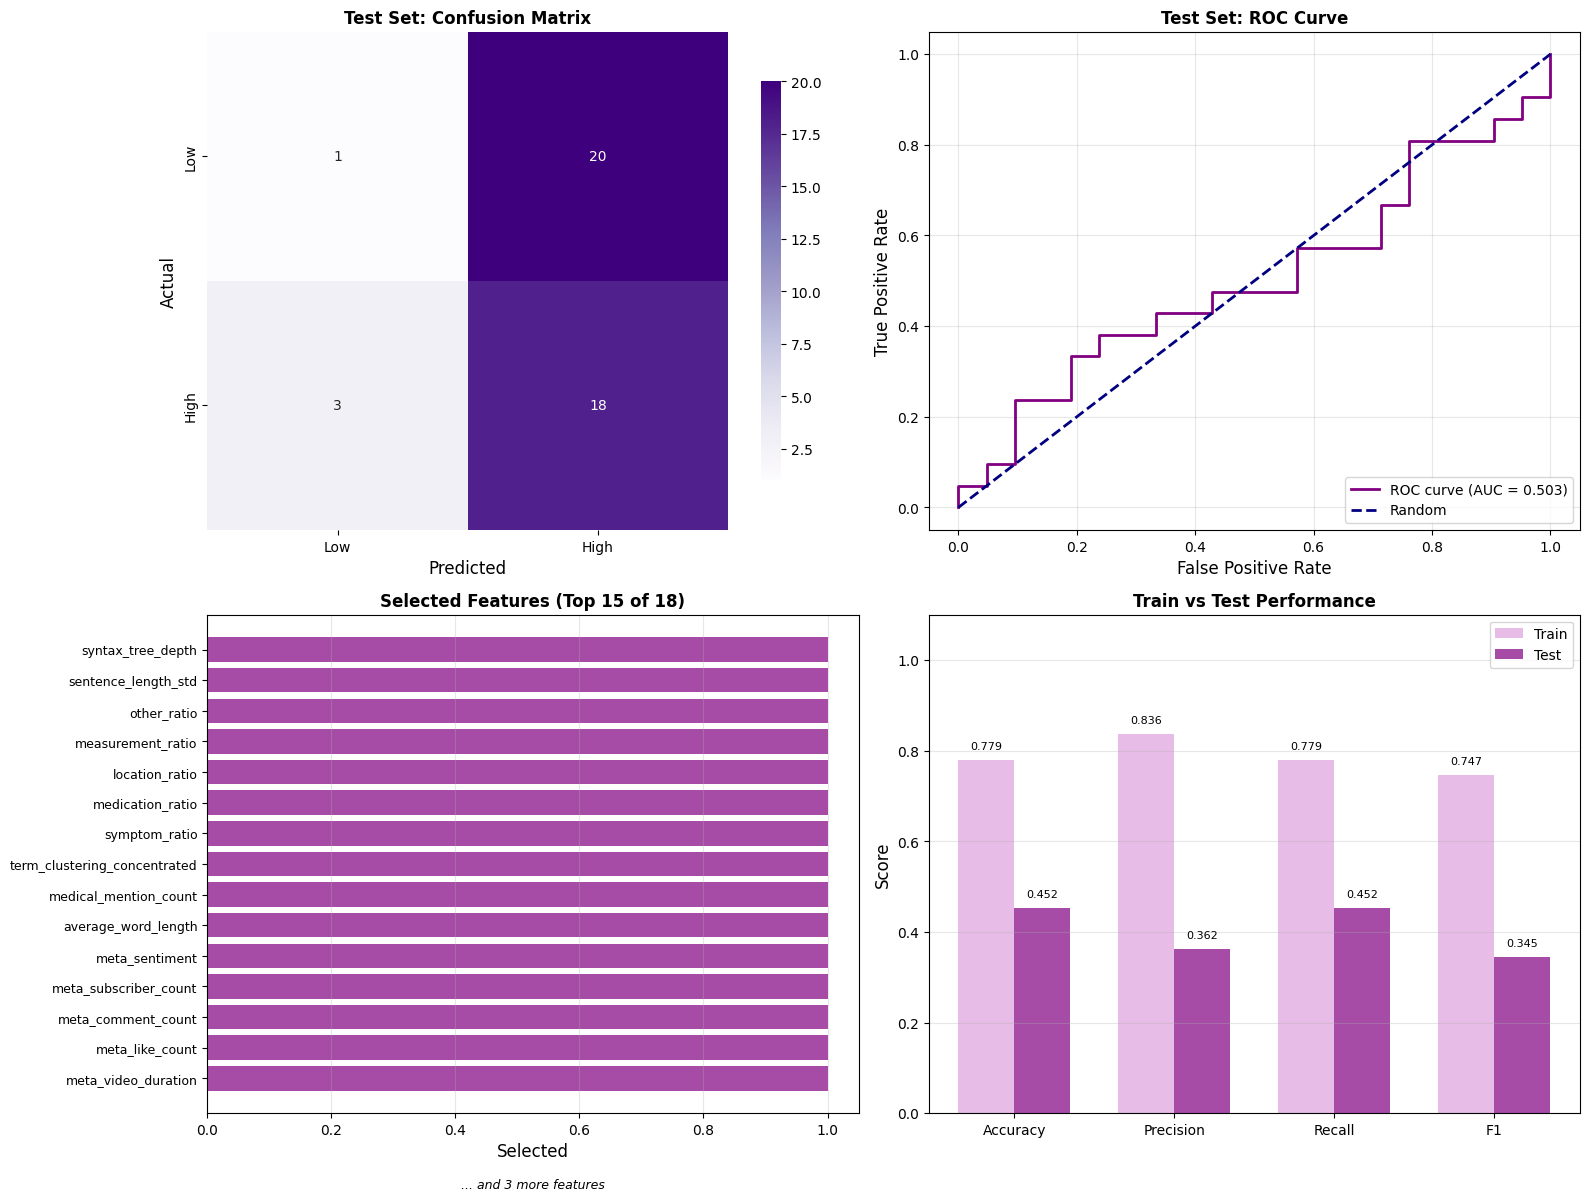


📋 All Selected Features (18):
    1. meta_video_duration
    2. meta_like_count
    3. meta_comment_count
    4. meta_subscriber_count
    5. meta_sentiment
    6. average_word_length
    7. medical_mention_count
    8. term_clustering_concentrated
    9. symptom_ratio
   10. medication_ratio
   11. location_ratio
   12. measurement_ratio
   13. other_ratio
   14. sentence_length_std
   15. syntax_tree_depth
   16. subordinate_clause_density
   17. average_dependency_distance
   18. pronoun_frequency



In [ ]:

# ============================================================================
# SVM: Visualization and Detailed Analysis
# ============================================================================

print("=" * 80)
print("SVM: Visualization and Detailed Analysis")
print("=" * 80)

# Confusion Matrix (use binary predictions from evaluation function)
cm_test_svm = eval_test_svm['confusion_matrix']

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(eval_test_svm['y_true_binary'], eval_test_svm['y_pred_binary'], target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Purples', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if eval_test_svm['y_pred_proba'] is not None and eval_test_svm['classification_metrics']['auc'] is not None:
    fpr_svm, tpr_svm, _ = roc_curve(eval_test_svm['y_true_binary'], eval_test_svm['y_pred_proba'])
    roc_auc_svm = eval_test_svm['classification_metrics']['auc']
    ax2.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_svm:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features
ax3 = axes[1, 0]
if len(selected_features_svm) > 0:
    features_to_show = selected_features_svm[:15] if len(selected_features_svm) > 15 else selected_features_svm
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='purple', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features_svm)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features_svm) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features_svm) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Train vs Test Performance Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_metrics_svm = [
    eval_train_svm['classification_metrics']['accuracy'],
    eval_train_svm['classification_metrics']['precision'],
    eval_train_svm['classification_metrics']['recall'],
    eval_train_svm['classification_metrics']['f1']
]
test_metrics_svm = [
    eval_test_svm['classification_metrics']['accuracy'],
    eval_test_svm['classification_metrics']['precision'],
    eval_test_svm['classification_metrics']['recall'],
    eval_test_svm['classification_metrics']['f1']
]

x_pos = np.arange(len(metrics))
width = 0.35
ax4.bar(x_pos - width/2, train_metrics_svm, width, label='Train', color='plum', alpha=0.7)
ax4.bar(x_pos + width/2, test_metrics_svm, width, label='Test', color='purple', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_metrics_svm, test_metrics_svm)):
    ax4.text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    ax4.text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features_svm)}):")
print("=" * 80)
for i, feat in enumerate(selected_features_svm, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


In [ ]:

# ============================================================================
# SAVE SVM MODEL AND RESULTS
# ============================================================================

import pickle
import json
from datetime import datetime

print("=" * 80)
print("SAVING SVM MODEL AND RESULTS")
print("=" * 80)

# Save best model
model_filename_svm = "data/best_svm_model.pkl"
with open(model_filename_svm, 'wb') as f:
    pickle.dump(best_model_svm, f)
print(f"✅ Best SVM model saved to: {model_filename_svm}")

# Get SVR info
best_svm = best_model_svm.named_steps['regression']

# Save model metadata
metadata_svm = {
    'model_name': 'SVR (Support Vector Regression) with Feature Selection',
    'problem_type': 'regression_with_classification_evaluation',
    'threshold': 0.8,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_selected_features': len(selected_features_svm),
    'selected_features': selected_features_svm,
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0],
    'best_parameters': grid_search_svm.best_params_,
    'best_cv_score': float(grid_search_svm.best_score_),
    'svr_configuration': {
        'kernel': best_svm.kernel,
        'C': float(best_svm.C),
        'gamma': str(best_svm.gamma),
        'degree': int(best_svm.degree) if best_svm.kernel == 'poly' else None,
        'coef0': float(best_svm.coef0) if best_svm.kernel in ['poly', 'sigmoid'] else None,
        'epsilon': float(best_svm.epsilon),
        'shrinking': bool(best_svm.shrinking)
    },
    'regression_metrics': {
        'train_r2': float(train_r2_svm),
        'test_r2': float(test_r2_svm),
        'train_rmse': float(train_rmse_svm),
        'test_rmse': float(test_rmse_svm),
        'train_mae': float(train_mae_svm),
        'test_mae': float(test_mae_svm),
        'overfitting_gap_r2': float(overfitting_gap_r2_svm)
    },
    'classification_metrics': {
        'train_accuracy': float(eval_train_svm['classification_metrics']['accuracy']),
        'test_accuracy': float(eval_test_svm['classification_metrics']['accuracy']),
        'train_precision': float(eval_train_svm['classification_metrics']['precision']),
        'test_precision': float(eval_test_svm['classification_metrics']['precision']),
        'train_recall': float(eval_train_svm['classification_metrics']['recall']),
        'test_recall': float(eval_test_svm['classification_metrics']['recall']),
        'train_f1': float(eval_train_svm['classification_metrics']['f1']),
        'test_f1': float(eval_test_svm['classification_metrics']['f1']),
        'overfitting_gap_acc': float(overfitting_gap_acc_svm)
    }
}

if eval_train_svm['classification_metrics']['auc'] is not None:
    metadata_svm['classification_metrics']['train_auc'] = float(eval_train_svm['classification_metrics']['auc'])
if eval_test_svm['classification_metrics']['auc'] is not None:
    metadata_svm['classification_metrics']['test_auc'] = float(eval_test_svm['classification_metrics']['auc'])

if cv_train_score is not None:
    metadata_svm['cv_metrics'] = {
        'train_cv_score': float(cv_train_score),
        'test_cv_score': float(cv_test_score),
        'cv_overfitting_gap': float(cv_overfitting_gap) if cv_overfitting_gap is not None else None
    }

metadata_filename_svm = "data/best_svm_metadata.json"
with open(metadata_filename_svm, 'w') as f:
    json.dump(metadata_svm, f, indent=2)
print(f"✅ SVM model metadata saved to: {metadata_filename_svm}")

# Save selected features
selected_features_df_svm = pd.DataFrame({
    'feature_name': selected_features_svm,
    'rank': range(1, len(selected_features_svm) + 1)
})
selected_features_df_svm.to_csv('data/svm_selected_features.csv', index=False)
print(f"✅ Selected features saved to: data/svm_selected_features.csv")

print("\n" + "=" * 80)
print("SVM MODEL SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Model file: {model_filename_svm}")
print(f"   • Metadata file: {metadata_filename_svm}")
print(f"   • Selected features: data/svm_selected_features.csv")
print(f"   • Best kernel: {best_svm.kernel}")
print(f"   • C (regularization): {best_svm.C}")
print(f"   • Gamma: {best_svm.gamma}")
print(f"   • Overfitting gap (R²): {overfitting_gap_r2_svm:.4f}")
print(f"   • Overfitting gap (Accuracy): {overfitting_gap_acc_svm:.4f}")
print("\n💡 To load the model later:")
print(f"   import pickle")
print(f"   with open('{model_filename_svm}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print("=" * 80)


SAVING SVM MODEL AND RESULTS
✅ Best SVM model saved to: data/best_svm_model.pkl
✅ SVM model metadata saved to: data/best_svm_metadata.json
✅ Selected features saved to: data/svm_selected_features.csv

SVM MODEL SAVED SUCCESSFULLY!

📝 Summary:
   • Model file: data/best_svm_model.pkl
   • Metadata file: data/best_svm_metadata.json
   • Selected features: data/svm_selected_features.csv
   • Best kernel: poly
   • C (regularization): 0.5
   • Gamma: scale
   • Overfitting gap: 0.3262

💡 To load the model later:
   import pickle
   with open('data/best_svm_model.pkl', 'rb') as f:
       model = pickle.load(f)


In [40]:
# ============================================================================
# MLP REGRESSOR: Feature Selection + Hyperparameter Tuning (Anti-Overfitting)
# ============================================================================
# Use Pipeline with feature selection and GridSearchCV
# MLPRegressor (Multi-Layer Perceptron) for regression
# ============================================================================

# Import necessary modules (in case cell 0 wasn't run)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

print("=" * 80)
print("MLP REGRESSOR: Feature Selection + Hyperparameter Tuning")
print("=" * 80)

# Check if data is prepared
try:
    X_train_check = X_train
    y_train_check = y_train
    print("✅ Data is prepared. Proceeding with MLPRegressor optimization...")
    
except NameError:
    print("⚠️  WARNING: Data not prepared yet. Please run Cell 4 (DATA PREPARATION) first!")
    print("   This cell will be skipped.")
    raise

# Create pipeline with StandardScaler, feature selection, and MLPRegressor
# StandardScaler is recommended for neural networks
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # StandardScaler for neural networks
    ('feature_selection', SelectKBest(f_regression)),  # Default, will be tuned
    ('regression', MLPRegressor(random_state=42, max_iter=1000))
])

# Parameter grid for optimization (focus on preventing overfitting)
param_grid_mlp = {
    # Feature selection method and number of features
    'feature_selection__score_func': [
        f_regression,           # F-test for regression
        mutual_info_regression, # Mutual information for regression
    ],
    'feature_selection__k': [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80],
    
    # MLPRegressor hyperparameters
    'regression__hidden_layer_sizes': [
        (50,), (100,), (150,), (50, 50), (100, 50), (100, 100)
    ],  # Network architecture
    'regression__activation': ['relu', 'tanh', 'logistic'],  # Activation function
    'regression__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0],  # L2 regularization (prevents overfitting)
    'regression__learning_rate': ['constant', 'adaptive'],  # Learning rate schedule
    'regression__learning_rate_init': [0.001, 0.01, 0.1],  # Initial learning rate
    'regression__solver': ['adam', 'lbfgs']  # Solver algorithm
}

# K-Fold for cross-validation (regression, not stratified)
cv_mlp = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate total parameter combinations
total_combinations_mlp = (len(param_grid_mlp['feature_selection__score_func']) * 
                         len(param_grid_mlp['feature_selection__k']) * 
                         len(param_grid_mlp['regression__hidden_layer_sizes']) *
                         len(param_grid_mlp['regression__activation']) *
                         len(param_grid_mlp['regression__alpha']) *
                         len(param_grid_mlp['regression__learning_rate']) *
                         len(param_grid_mlp['regression__learning_rate_init']) *
                         len(param_grid_mlp['regression__solver']))

print(f"\n🚀 Starting GridSearchCV optimization for MLPRegressor...")
print(f"   Feature selection methods: {len(param_grid_mlp['feature_selection__score_func'])} options")
print(f"     - f_regression: F-test for regression")
print(f"     - mutual_info_regression: Mutual information for regression")
print(f"   Feature selection k values: {len(param_grid_mlp['feature_selection__k'])} options")
print(f"   Hidden layer sizes: {len(param_grid_mlp['regression__hidden_layer_sizes'])} options")
print(f"   Activation: {len(param_grid_mlp['regression__activation'])} options")
print(f"   Alpha (L2 regularization): {len(param_grid_mlp['regression__alpha'])} options")
print(f"   Learning rate: {len(param_grid_mlp['regression__learning_rate'])} options")
print(f"   Learning rate init: {len(param_grid_mlp['regression__learning_rate_init'])} options")
print(f"   Solver: {len(param_grid_mlp['regression__solver'])} options")
print(f"   Total parameter combinations: {total_combinations_mlp:,}")
print(f"   With 5-fold CV: {total_combinations_mlp * 5:,} model fits")

# Time estimation
estimated_seconds = total_combinations_mlp * 5 * 2  # MLP is slower (~2s per fit)
estimated_minutes = estimated_seconds / 60
estimated_hours = estimated_minutes / 60

print(f"\n⏱️  Estimated Time (with parallelization):")
if estimated_hours < 1:
    print(f"   Best case: ~{estimated_minutes/2:.1f} minutes")
    print(f"   Average case: ~{estimated_minutes:.1f} minutes")
    print(f"   Worst case: ~{estimated_minutes*2:.1f} minutes")
else:
    print(f"   Best case: ~{estimated_hours/2:.2f} hours ({estimated_minutes/2:.1f} minutes)")
    print(f"   Average case: ~{estimated_hours:.2f} hours ({estimated_minutes:.1f} minutes)")
    print(f"   Worst case: ~{estimated_hours*2:.2f} hours ({estimated_minutes*2:.1f} minutes)")
print(f"\n💡 Note: MLPRegressor with {total_combinations_mlp:,} combinations may take a while.")
print(f"   Alpha parameter (L2 regularization) controls overfitting:")
print(f"   - Small alpha (< 0.01): Less regularization, may overfit")
print(f"   - Medium alpha (0.01-0.1): Moderate regularization, balanced")
print(f"   - Large alpha (> 0.1): More regularization, prevents overfitting")
print("=" * 80)

# Grid search
print("\n📊 Starting optimization...")
print("   (This may take a while. Progress will be shown below.)\n")

start_time_mlp = time.time()

grid_search_mlp = GridSearchCV(
    mlp_pipeline,
    param_grid_mlp,
    cv=cv_mlp,
    scoring='r2',  # Use R² for regression
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
    return_train_score=True  # Return training scores for overfitting check
)

# Fit grid search (use continuous y)
grid_search_mlp.fit(X_train, y_train)

elapsed_time_mlp = time.time() - start_time_mlp

print(f"\n✅ Optimization completed!")
print(f"   Total time: {elapsed_time_mlp/60:.1f} minutes ({elapsed_time_mlp:.1f} seconds)")

# Get best parameters from GridSearchCV
best_params_mlp = grid_search_mlp.best_params_

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE!")
print("=" * 80)

# Display best parameters and CV score
print(f"\n🏆 Best Parameters (from GridSearchCV):")
for param, value in best_params_mlp.items():
    if param == 'feature_selection__score_func':
        # Display function name instead of function object
        func_name = value.__name__ if hasattr(value, '__name__') else str(value)
        print(f"   {param}: {func_name}")
    else:
        print(f"   {param}: {value}")

print(f"\n📊 Best CV Score (R²): {grid_search_mlp.best_score_:.4f}")

# ============================================================================
# RETRAIN ON FULL TRAINING SET WITH BEST PARAMETERS
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

print("\n🔄 Retraining model on FULL training set with best parameters...")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Features: {X_train.shape[1]}")

# Create a new pipeline with best parameters
# Use the best feature selection method from grid search
best_score_func_mlp = best_params_mlp['feature_selection__score_func']
best_pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),  # StandardScaler for neural networks
    ('feature_selection', SelectKBest(score_func=best_score_func_mlp, k=best_params_mlp['feature_selection__k'])),
    ('regression', MLPRegressor(
        hidden_layer_sizes=best_params_mlp['regression__hidden_layer_sizes'],
        activation=best_params_mlp['regression__activation'],
        alpha=best_params_mlp['regression__alpha'],
        learning_rate=best_params_mlp['regression__learning_rate'],
        learning_rate_init=best_params_mlp['regression__learning_rate_init'],
        solver=best_params_mlp['regression__solver'],
        random_state=42,
        max_iter=1000
    ))
])

# Retrain on FULL training set (use continuous y)
best_pipeline_mlp.fit(X_train, y_train)

# Use this as the final model
best_model_mlp = best_pipeline_mlp

print("✅ Model retrained on FULL training set!")
print("=" * 80)

# Get selected features
selected_features_mask_mlp = best_model_mlp.named_steps['feature_selection'].get_support()
selected_features_mlp = [feature_names[i] for i in range(len(feature_names)) if selected_features_mask_mlp[i]]
n_selected_features_mlp = len(selected_features_mlp)

print(f"\n📋 Selected Features: {n_selected_features_mlp} out of {len(feature_names)}")

# Display MLP info
best_mlp = best_model_mlp.named_steps['regression']
print(f"\n🔧 MLPRegressor Configuration:")
print(f"   Feature selection method: {best_score_func_mlp.__name__}")
print(f"   Number of selected features: {best_params_mlp['feature_selection__k']}")
print(f"   Hidden layer sizes: {best_mlp.hidden_layer_sizes}")
print(f"   Activation: {best_mlp.activation}")
print(f"   Alpha (L2 regularization): {best_mlp.alpha}")
print(f"   Learning rate: {best_mlp.learning_rate}")
print(f"   Learning rate init: {best_mlp.learning_rate_init}")
print(f"   Solver: {best_mlp.solver}")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print(f"\n📊 Test Set Information:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Features: {X_test.shape[1]}")

# ============================================================================
# FINAL EVALUATION: Make predictions on test set
# ============================================================================
print("\n🔍 Making predictions on test set with retrained model...")

# Make predictions (continuous values)
y_train_pred_mlp = best_model_mlp.predict(X_train)
y_test_pred_mlp = best_model_mlp.predict(X_test)

print("✅ Predictions completed!")
print(f"   Training predictions: {len(y_train_pred_mlp)} samples")
print(f"   Test predictions: {len(y_test_pred_mlp)} samples")

# Evaluate as regression
train_r2_mlp = r2_score(y_train, y_train_pred_mlp)
test_r2_mlp = r2_score(y_test, y_test_pred_mlp)
train_rmse_mlp = np.sqrt(mean_squared_error(y_train, y_train_pred_mlp))
test_rmse_mlp = np.sqrt(mean_squared_error(y_test, y_test_pred_mlp))
train_mae_mlp = mean_absolute_error(y_train, y_train_pred_mlp)
test_mae_mlp = mean_absolute_error(y_test, y_test_pred_mlp)

# Evaluate as classification (using threshold)
eval_train_mlp = evaluate_regression_as_classification(y_train, y_train_pred_mlp, threshold)
eval_test_mlp = evaluate_regression_as_classification(y_test, y_test_pred_mlp, threshold)

# Check for overfitting (difference between train and test R²)
overfitting_gap_r2_mlp = train_r2_mlp - test_r2_mlp
overfitting_gap_acc_mlp = eval_train_mlp['classification_metrics']['accuracy'] - eval_test_mlp['classification_metrics']['accuracy']

# Check train vs test scores from CV
if 'mean_train_score' in grid_search_mlp.cv_results_:
    mean_train_scores = grid_search_mlp.cv_results_['mean_train_score']
    mean_test_scores = grid_search_mlp.cv_results_['mean_test_score']
    best_idx = grid_search_mlp.best_index_
    cv_train_score_mlp = mean_train_scores[best_idx]
    cv_test_score_mlp = mean_test_scores[best_idx]
    cv_overfitting_gap_mlp = cv_train_score_mlp - cv_test_score_mlp
else:
    cv_train_score_mlp = None
    cv_test_score_mlp = None
    cv_overfitting_gap_mlp = None

# Display performance metrics
print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(f"\n📊 Cross-Validation Performance:")
print(f"   Train CV Score (R²): {cv_train_score_mlp:.4f}" if cv_train_score_mlp is not None else "   Train CV Score: N/A")
print(f"   Test CV Score (R²): {grid_search_mlp.best_score_:.4f}")
if cv_overfitting_gap_mlp is not None:
    print(f"   CV Overfitting Gap (R²): {cv_overfitting_gap_mlp:.4f}")
    if cv_overfitting_gap_mlp > 0.15:
        print(f"   ⚠️  WARNING: Large CV gap detected! Model may be overfitting.")
    elif cv_overfitting_gap_mlp > 0.10:
        print(f"   ⚠️  CAUTION: Moderate CV gap detected.")
    else:
        print(f"   ✅ Good: CV gap is acceptable.")

print(f"\n📊 REGRESSION Performance (Training Set):")
print(f"   R²:   {train_r2_mlp:.4f}")
print(f"   RMSE: {train_rmse_mlp:.4f}")
print(f"   MAE:  {train_mae_mlp:.4f}")

print(f"\n📊 REGRESSION Performance (Test Set - FINAL EVALUATION):")
print(f"   ✅ Final Test R²:   {test_r2_mlp:.4f}")
print(f"   ✅ Final Test RMSE: {test_rmse_mlp:.4f}")
print(f"   ✅ Final Test MAE:  {test_mae_mlp:.4f}")

print(f"\n📊 CLASSIFICATION Performance (at threshold={threshold}):")
print(f"\n   Training Set:")
print(f"   Accuracy:  {eval_train_mlp['classification_metrics']['accuracy']:.4f}")
print(f"   Precision: {eval_train_mlp['classification_metrics']['precision']:.4f}")
print(f"   Recall:    {eval_train_mlp['classification_metrics']['recall']:.4f}")
print(f"   F1 Score:  {eval_train_mlp['classification_metrics']['f1']:.4f}")
if eval_train_mlp['classification_metrics']['auc'] is not None:
    print(f"   AUC-ROC:   {eval_train_mlp['classification_metrics']['auc']:.4f}")

print(f"\n   Test Set (FINAL EVALUATION):")
print(f"   ✅ Final Test Accuracy:  {eval_test_mlp['classification_metrics']['accuracy']:.4f}")
print(f"   ✅ Final Test Precision: {eval_test_mlp['classification_metrics']['precision']:.4f}")
print(f"   ✅ Final Test Recall:    {eval_test_mlp['classification_metrics']['recall']:.4f}")
print(f"   ✅ Final Test F1 Score:  {eval_test_mlp['classification_metrics']['f1']:.4f}")
if eval_test_mlp['classification_metrics']['auc'] is not None:
    print(f"   ✅ Final Test AUC-ROC:   {eval_test_mlp['classification_metrics']['auc']:.4f}")
print(f"\n   📝 Note: This is the performance on the test set using the model")
print(f"      trained on the FULL training set with best parameters.")

print(f"\n⚠️  Overfitting Check (Train vs Test):")
print(f"   Train-Test R² Gap: {overfitting_gap_r2_mlp:.4f}")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_acc_mlp:.4f}")
if overfitting_gap_r2_mlp > 0.15 or overfitting_gap_acc_mlp > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    print(f"   💡 Consider increasing alpha (L2 regularization) to reduce overfitting.")
elif overfitting_gap_r2_mlp > 0.10 or overfitting_gap_acc_mlp > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
    print(f"   💡 Consider slightly increasing alpha if gap increases.")
else:
    print(f"   ✅ Good: Gap is acceptable.")
    print(f"   💡 Current alpha ({best_mlp.alpha}) provides good regularization.")

print("\n" + "=" * 80)


MLP REGRESSOR: Feature Selection + Hyperparameter Tuning
✅ Data is prepared. Proceeding with MLPRegressor optimization...

🚀 Starting GridSearchCV optimization for MLPRegressor...
   Feature selection methods: 2 options
     - f_regression: F-test for regression
     - mutual_info_regression: Mutual information for regression
   Feature selection k values: 12 options
   Hidden layer sizes: 6 options
   Activation: 3 options
   Alpha (L2 regularization): 5 options
   Learning rate: 2 options
   Learning rate init: 3 options
   Solver: 2 options
   Total parameter combinations: 25,920
   With 5-fold CV: 129,600 model fits

⏱️  Estimated Time (with parallelization):
   Best case: ~36.00 hours (2160.0 minutes)
   Average case: ~72.00 hours (4320.0 minutes)
   Worst case: ~144.00 hours (8640.0 minutes)

💡 Note: MLPRegressor with 25,920 combinations may take a while.
   Alpha parameter (L2 regularization) controls overfitting:
   - Small alpha (< 0.01): Less regularization, may overfit
   - 


✅ Optimization completed!
   Total time: 23.4 minutes (1401.2 seconds)

OPTIMIZATION COMPLETE!

🏆 Best Parameters (from GridSearchCV):
   feature_selection__k: 15
   feature_selection__score_func: mutual_info_regression
   regression__activation: logistic
   regression__alpha: 1.0
   regression__hidden_layer_sizes: (150,)
   regression__learning_rate: adaptive
   regression__learning_rate_init: 0.001
   regression__solver: lbfgs

📊 Best CV Score (R²): 0.0071

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Retraining model on FULL training set with best parameters...
   Training samples: 140
   Features: 31
✅ Model retrained on FULL training set!

📋 Selected Features: 15 out of 31

🔧 MLPRegressor Configuration:
   Feature selection method: mutual_info_regression
   Number of selected features: 15
   Hidden layer sizes: (150,)
   Activation: logistic
   Alpha (L2 regularization): 1.0
   Learning rate: adaptive
   Learning rate init: 0.001
   Solver: lbfgs

EVALUATING ON TEST SE

In [41]:
# ============================================================================
# MULTINOMIAL NB: Visualization and Detailed Analysis
# ============================================================================

print("=" * 80)
print("MULTINOMIAL NB: Visualization and Detailed Analysis")
print("=" * 80)

# Confusion Matrix
cm_test_nb = confusion_matrix(y_test_binary_aligned, y_test_pred_nb)

# Classification Report
print(f"\n📊 Classification Report (Test Set):")
print("=" * 80)
print(classification_report(y_test_binary_aligned, y_test_pred_nb, target_names=['Low', 'High']))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_test_nb, annot=True, fmt='d', cmap='Reds', ax=ax1, cbar_kws={'shrink': 0.8},
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title('Test Set: Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 2: ROC Curve
ax2 = axes[0, 1]
if y_test_proba_nb is not None:
    fpr_nb, tpr_nb, _ = roc_curve(y_test_binary_aligned, y_test_proba_nb)
    roc_auc_nb = auc(fpr_nb, tpr_nb)
    ax2.plot(fpr_nb, tpr_nb, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc_nb:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('Test Set: ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right")
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'ROC curve not available', 
            ha='center', va='center', fontsize=12, transform=ax2.transAxes)
    ax2.set_title('ROC Curve (Not Available)', fontsize=12, fontweight='bold')

# Plot 3: Selected Features
ax3 = axes[1, 0]
if len(selected_features_nb) > 0:
    features_to_show = selected_features_nb[:15] if len(selected_features_nb) > 15 else selected_features_nb
    ax3.barh(range(len(features_to_show)), [1] * len(features_to_show), color='red', alpha=0.7)
    ax3.set_yticks(range(len(features_to_show)))
    ax3.set_yticklabels([f[:30] for f in features_to_show], fontsize=9)
    ax3.set_xlabel('Selected', fontsize=12)
    ax3.set_title(f'Selected Features (Top {len(features_to_show)} of {len(selected_features_nb)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    if len(selected_features_nb) > 15:
        ax3.text(0.5, -0.15, f'... and {len(selected_features_nb) - 15} more features', 
                ha='center', transform=ax3.transAxes, fontsize=9, style='italic')
else:
    ax3.text(0.5, 0.5, 'No features selected', 
            ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Selected Features', fontsize=12, fontweight='bold')

# Plot 4: Train vs Test Performance Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
train_metrics_nb = [train_acc_nb, train_precision_nb, train_recall_nb, train_f1_nb]
test_metrics_nb = [test_acc_nb, test_precision_nb, test_recall_nb, test_f1_nb]

x_pos = np.arange(len(metrics))
width = 0.35
ax4.bar(x_pos - width/2, train_metrics_nb, width, label='Train', color='lightcoral', alpha=0.7)
ax4.bar(x_pos + width/2, test_metrics_nb, width, label='Test', color='darkred', alpha=0.7)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics, fontsize=10)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Train vs Test Performance', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_metrics_nb, test_metrics_nb)):
    ax4.text(i - width/2, train_val + 0.02, f'{train_val:.3f}', ha='center', va='bottom', fontsize=8)
    ax4.text(i + width/2, test_val + 0.02, f'{test_val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Display all selected features
print(f"\n📋 All Selected Features ({len(selected_features_nb)}):")
print("=" * 80)
for i, feat in enumerate(selected_features_nb, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)


MULTINOMIAL NB: Visualization and Detailed Analysis


NameError: name 'y_test_pred_nb' is not defined

In [ ]:
# ============================================================================
# SAVE MULTINOMIAL NB MODEL AND RESULTS
# ============================================================================

import pickle
import json
from datetime import datetime

print("=" * 80)
print("SAVING MULTINOMIAL NB MODEL AND RESULTS")
print("=" * 80)

# Verify that best_model_nb is the retrained model
print("\n🔍 Verifying model to save...")
if hasattr(best_model_nb, 'named_steps'):
    print("✅ Model is a Pipeline (retrained model)")
    print(f"   Model type: {type(best_model_nb).__name__}")
    print(f"   This model was trained on FULL training set ({X_train.shape[0]} samples)")
else:
    print("⚠️  WARNING: Model structure unexpected")

# Save best model (this is the model retrained on FULL training set)
model_filename_nb = "data/best_multinomial_nb_model.pkl"
with open(model_filename_nb, 'wb') as f:
    pickle.dump(best_model_nb, f)
print(f"\n✅ Best MultinomialNB model saved to: {model_filename_nb}")
print(f"   📝 Note: This model was trained on FULL training set with best parameters")

# Get NB info
best_nb = best_model_nb.named_steps['classification']

# Ensure best_params_nb exists
if 'best_params_nb' not in locals():
    try:
        best_params_nb = grid_search_nb.best_params_
        print("⚠️  Note: Using best_params from grid_search_nb (retraining cell may not have been run)")
    except NameError:
        print("⚠️  ERROR: best_params_nb not found. Please run the MultinomialNB training cell first!")
        raise

# Save model metadata
metadata_nb = {
    'model_name': 'Multinomial Naive Bayes with Feature Selection',
    'problem_type': 'binary_classification',
    'threshold': 0.8,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': X_train.shape[1],
    'n_selected_features': len(selected_features_nb),
    'selected_features': selected_features_nb,
    'n_train_samples': X_train.shape[0],
    'n_test_samples': X_test.shape[0],
    'best_parameters': best_params_nb,
    'best_cv_score': float(grid_search_nb.best_score_),
    'training_note': 'Model was retrained on FULL training set with best parameters from GridSearchCV',
    'nb_configuration': {
        'alpha': float(best_nb.alpha),
        'fit_prior': bool(best_nb.fit_prior),
        'class_prior': best_nb.class_prior.tolist() if best_nb.class_prior is not None else None
    },
    'metrics': {
        'train_accuracy': float(train_acc_nb),
        'test_accuracy': float(test_acc_nb),
        'train_precision': float(train_precision_nb),
        'test_precision': float(test_precision_nb),
        'train_recall': float(train_recall_nb),
        'test_recall': float(test_recall_nb),
        'train_f1': float(train_f1_nb),
        'test_f1': float(test_f1_nb),
        'overfitting_gap': float(overfitting_gap_nb)
    }
}

if train_auc_nb is not None:
    metadata_nb['metrics']['train_auc'] = float(train_auc_nb)
if test_auc_nb is not None:
    metadata_nb['metrics']['test_auc'] = float(test_auc_nb)

if cv_train_score is not None:
    metadata_nb['cv_metrics'] = {
        'train_cv_score': float(cv_train_score),
        'test_cv_score': float(cv_test_score),
        'cv_overfitting_gap': float(cv_overfitting_gap_nb) if cv_overfitting_gap_nb is not None else None
    }

metadata_filename_nb = "data/best_multinomial_nb_metadata.json"
with open(metadata_filename_nb, 'w') as f:
    json.dump(metadata_nb, f, indent=2)
print(f"✅ MultinomialNB model metadata saved to: {metadata_filename_nb}")

# Save selected features
selected_features_df_nb = pd.DataFrame({
    'feature_name': selected_features_nb,
    'rank': range(1, len(selected_features_nb) + 1)
})
selected_features_df_nb.to_csv('data/multinomial_nb_selected_features.csv', index=False)
print(f"✅ Selected features saved to: data/multinomial_nb_selected_features.csv")

print("\n" + "=" * 80)
print("MULTINOMIAL NB MODEL SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Model file: {model_filename_nb}")
print(f"   • Metadata file: {metadata_filename_nb}")
print(f"   • Selected features: data/multinomial_nb_selected_features.csv")
print(f"   • Alpha (smoothing): {best_nb.alpha}")
print(f"   • Fit prior: {best_nb.fit_prior}")
print(f"   • Overfitting gap: {overfitting_gap_nb:.4f}")
print("\n💡 To load the model later:")
print(f"   import pickle")
print(f"   with open('{model_filename_nb}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print("=" * 80)


SAVING MULTINOMIAL NB MODEL AND RESULTS

🔍 Verifying model to save...
✅ Model is a Pipeline (retrained model)
   Model type: Pipeline
   This model was trained on FULL training set (140 samples)

✅ Best MultinomialNB model saved to: data/best_multinomial_nb_model.pkl
   📝 Note: This model was trained on FULL training set with best parameters


AttributeError: 'list' object has no attribute 'tolist'